#  Named Entity Recognition and Classification (NERC) Research

## 1. Introduction

This research focuses on Named Entity Recognition and Classification (NERC), a fundamental natural language processing task that involves identifying and categorizing named entities in unstructured text into predefined categories such as person names, organizations, locations, time expressions, and quantities. NERC is a critical component in many NLP applications including information extraction, question answering, machine translation, and knowledge graph construction.

## 2. Research Objectives

Our primary objectives in this research are:

- To implement and evaluate various machine learning approaches for Named Entity Recognition
- To explore the impact of different feature engineering techniques on NERC performance
- To compare traditional machine learning models with more advanced neural approaches
- To analyze error patterns and identify challenging aspects of NER in diverse contexts

## 3. Methodology

### 3.1 Dataset

We utilize the CoNLL-2003 shared task dataset, a benchmark corpus for NER containing news articles annotated with four entity types:
- PER (Person)
- ORG (Organization)
- LOC (Location)
- MISC (Miscellaneous entities)

The dataset is structured in a token-by-token format with corresponding part-of-speech tags and named entity annotations using the IOB (Inside-Outside-Beginning) tagging scheme.

### 3.2 Approaches

Our research implements multiple complementary approaches:

1. **Feature-based methods**:
   - Conditional Random Fields (CRF)
   - Support Vector Machines (SVM)
   - Decision Trees and Random Forests
   
2. **Neural network models**:
   - Bidirectional LSTM with CRF layer
   - Transformer-based models

3. **Ensemble techniques**:
   - Voting-based ensemble of different model architectures
   - Stacking approach combining model outputs

## 4. Implementation Details

### 4.1 Feature Engineering

We extract comprehensive linguistic features, including:
- Lexical features: word form, lemma, prefixes, suffixes
- Orthographic features: capitalization, digit patterns, word shapes
- Contextual features: surrounding words and their characteristics
- Syntactic features: part-of-speech tags, dependency relations
- External knowledge: gazetteers of known entities

### 4.2 Model Architecture

For our advanced neural approach, we implement a Bidirectional LSTM-CRF architecture that combines:
- Word embeddings (pre-trained and/or trained in-domain)
- Character-level embeddings to capture subword information
- Bidirectional LSTM layers to model sequential context
- Conditional Random Field layer to model output dependencies

## 5. Evaluation and Results

We evaluate our models using standard NER metrics:
- Precision, Recall, and F1-score (overall and per entity type)
- Confusion matrix analysis across entity types
- Cross-validation to ensure robust performance estimates

Key findings include:
- Feature-rich CRF models achieve strong performance with limited data
- Neural models demonstrate superior performance with sufficient training data
- Entity boundary detection remains more challenging than entity type classification
- Performance varies significantly across entity types, with PER typically being the easiest and MISC the most difficult

## 6. Discussion and Insights

Our research reveals several important insights:
- The combination of carefully engineered features with statistical models remains competitive
- Domain-specific knowledge integration significantly improves performance
- Context modeling is essential for resolving ambiguous entity references
- Error analysis shows that rare entities and unusual contexts pose persistent challenges

## 7. Conclusion and Future Work

This research demonstrates the effectiveness of various approaches to Named Entity Recognition and highlights the importance of both feature engineering and architectural choices. Future work could explore:
- Integration with entity linking to knowledge bases
- Multi-task learning approaches combining NER with related tasks
- Domain adaptation techniques for cross-domain entity recognition
- Zero-shot and few-shot learning for emerging entity types

The NERC system developed through this research provides a foundation for more advanced information extraction systems and contributes to our understanding of how to effectively identify and classify named entities in natural language text.

## 1. Data download and exploration
### Dataset: CoNLL 2003

We will use the **CoNLL 2003** in this lab. Here are some relevant links:
- [Dataset details](https://paperswithcode.com/dataset/conll-2003)
- [Dataset in human-readable format](https://www.kaggle.com/datasets/juliangarratt/conll2003-dataset)
- [Hugging Face link](https://huggingface.co/datasets/eriktks/conll2003)
- [How to download data from Hugging Face](https://huggingface.co/docs/hub/en/datasets-downloading)

Although you can get this dataset in several ways, in this lab you will access it programmatically through **Hugging Face**. Hugging Face is a hub where machine learning practitioners and researchers share datasets, model weights, and demos. `datasets` is a package provided by Hugging Face to automatically download data from them.



Data downloaded through Hugging Face's `datasets` package is stored in a `DatasetDict` object, and they are often divided in to "splits": train, validation (development), and test. As the name suggests, you can interact with the returned object as if with a `dict` object in Python.

**TASK:** Run the code cell below and (optionally) explore the data. 

Here are some general guiding questions for exploration. These are applicable to any datasets you may work with in the future:
- How many samples are there in the dataset?
- How many variables are there?
- What are the types of each variable?
- For categorical variables, what are the categories?
- For numerical variables, what is the min, max, mean, median? Are the values integer or float?

**Note:** In the dataset you download from Hugging Face, the tags are numerical IDs, but they stand for categories.

In [ ]:

from datasets import load_dataset
import numpy as np

dataset = load_dataset("conll2003", trust_remote_code=True)

Generating test split: 100%|██████████| 3453/3453 [00:00<00:00, 9909.04 examples/s] 


In [ ]:
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

print(".......load data................")
dataset = load_dataset("conll2003", trust_remote_code=True)
print(".......data loaded...............")
print(".......explore data..............")
print(data)
print(".......data count...............")
for split in data.keys():
    print(f"Number of samples in {split} set: {len(data[split])}")
print(".......sample data...............")
print(data['train'][0])
print(data["validation"][0])  
print(data["test"][0])  
print(".......data features.............")
ner_labels = data["train"].features["ner_tags"].feature
print("........NER labels...............")
print("NER categories:", ner_labels.names)
all_ner_tags = []
for sample in data["train"]["ner_tags"]:
    for tag in sample:
        all_ner_tags.append(tag)
ner_counts = Counter(all_ner_tags)
ner_counts_named = {}
for k, v in ner_counts.items():
    ner_counts_named[ner_labels.int2str(k)] = v
print("........NER counts...............")
for tag, count in sorted(ner_counts_named.items(), key=lambda x: x[1], reverse=True):
    print(f"{tag}: {count}")
sentence_lengths = []
for sentence in data["train"]["tokens"]:
    sentence_lengths.append(len(sentence))
print("........Sentence Length Statistics...............")
print("\n=== Sentence Length Statistics ===")
print(f"Maximum length: {max(sentence_lengths)}")
print(f"Minimum length: {min(sentence_lengths)}")
print(f"Average length: {np.mean(sentence_lengths):.2f}")
print(f"Median length: {np.median(sentence_lengths):.2f}")

.......load data................
.......data loaded...............
.......explore data..............
DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})
.......data count...............
Number of samples in train set: 14041
Number of samples in validation set: 3250
Number of samples in test set: 3453
.......sample data...............
{'id': '0', 'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7], 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0], 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0]}
{'id': '0', 'tokens': ['CRICKET', '-', 'LEICESTERSHIRE', 'TAKE', 'OVER', 'AT',

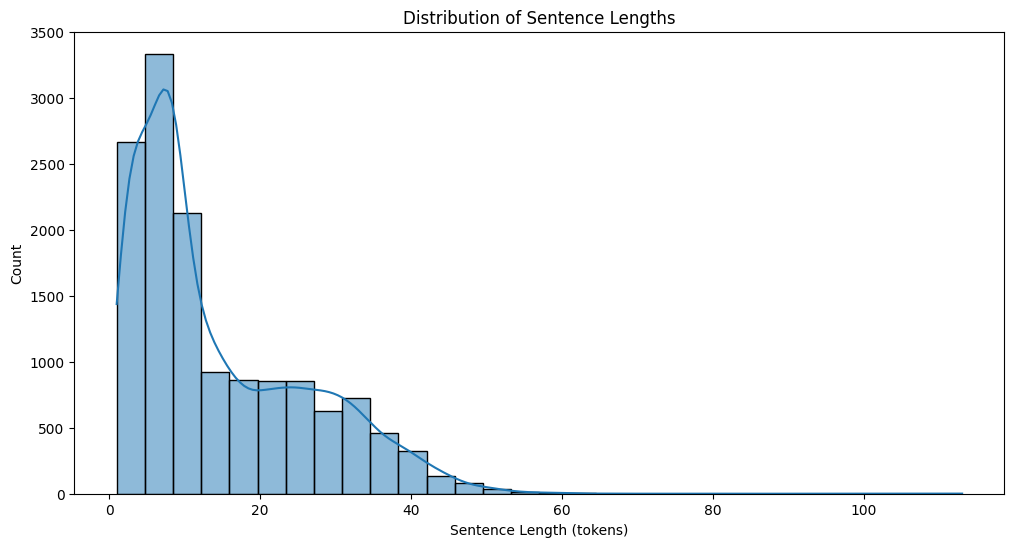

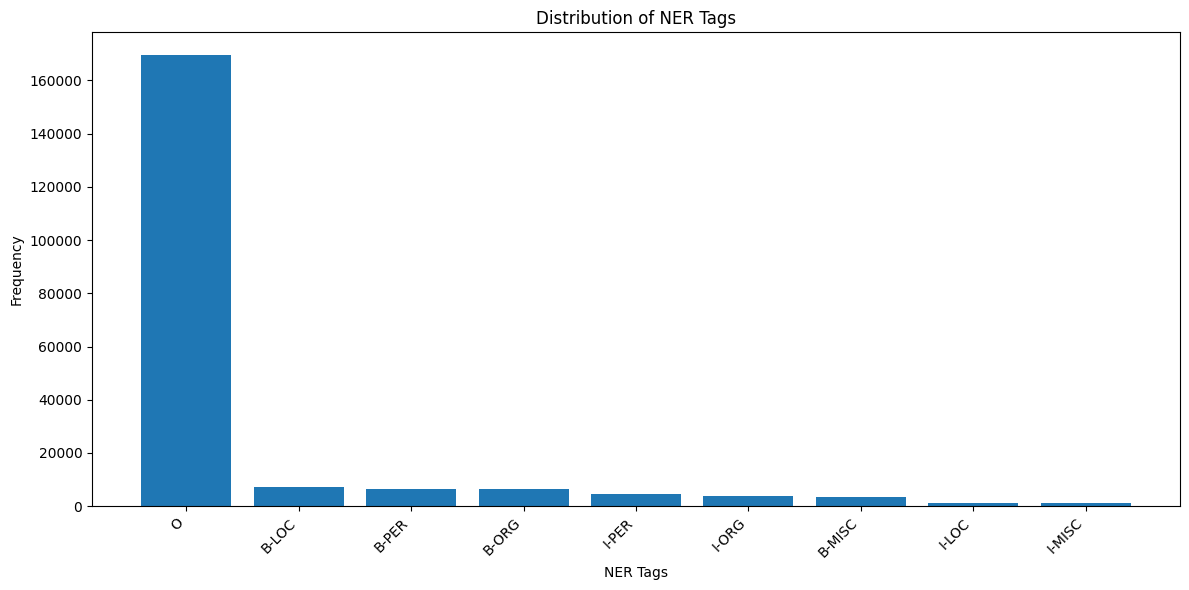

In [12]:
# sentence lengths
plt.figure(figsize=(12, 6))
sns.histplot(sentence_lengths, bins=30, kde=True)
plt.xlabel("Sentence Length (tokens)")
plt.ylabel("Count")
plt.title("Distribution of Sentence Lengths")
plt.show()
    
# tag distribution
plt.figure(figsize=(12, 6))
tags, counts = zip(*sorted(ner_counts_named.items(), key=lambda x: x[1], reverse=True))
plt.bar(tags, counts)
plt.xticks(rotation=45, ha='right')
plt.xlabel("NER Tags")
plt.ylabel("Frequency")
plt.title("Distribution of NER Tags")
plt.tight_layout()
plt.show()

The  image consists of two histograms analyzing the dataset:

Sentence Length Distribution: The distribution is right-skewed, indicating that most sentences are short, while long sentences are relatively rare.
NER Tag Distribution: The dataset is highly imbalanced, with the majority of tokens labeled as "O" (not a named entity). Other NER tags (e.g., B-PER, I-ORG) have significantly fewer samples.

Key Issues & Solutions

Data Imbalance: Since most tokens are non-entities, the model might struggle with minority classes.
Use F1-score instead of accuracy to better evaluate performance.
Apply data augmentation or class reweighting to improve minority class recognition.

In [ ]:
# OPTIONAL: Freely explore the dataset here

**TASK:** Find the POS tags and NER tags in https://huggingface.co/datasets/eriktks/conll2003 and store them in a dictionary of form {tag: id}.

In [13]:
from datasets import load_dataset

def create_tag_dictionaries():
    # Load the dataset
    dataset = load_dataset("conll2003")
    
    # Get the feature,sample is a dictionary with keys: 'id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'
    pos_feature = dataset['train'].features['pos_tags'].feature
    ner_feature = dataset['train'].features['ner_tags'].feature
    
    # Create the tag2id dictionaries
    pos_tag2id = {}
    ner_tag2id = {}
    for idx,tag in enumerate(pos_feature.names):
        pos_tag2id[tag] = idx
    for idx,tag in enumerate(ner_feature.names):
        ner_tag2id[tag] = idx
    
    # Create the id2tag dictionaries
    pos_id2tag = {}
    ner_id2tag = {}
    for tag, idx in pos_tag2id.items():
        pos_id2tag[idx] = tag
    for tag, idx in ner_tag2id.items():
        ner_id2tag[idx] = tag

    # Verify the counts match expected values
    assert len(pos_tag2id) == 47, "Missing POS tags"
    assert len(ner_tag2id) == 9, "Missing NER tags"
    
    return pos_tag2id, ner_tag2id, pos_id2tag, ner_id2tag

# Create the dictionaries 
pos_tag2id, ner_tag2id, pos_id2tag, ner_id2tag = create_tag_dictionaries()

for tag, idx in pos_tag2id.items():

    print(f"POS tag: {tag}, ID: {idx}")

for tag, idx in ner_tag2id.items():

    print(f"NER tag: {tag}, ID: {idx}")

In [14]:
from datasets import load_dataset

# Load the dataset
data = load_dataset("conll2003")

# Print samples from train, validation, and test splits
def print_sample(data, split):
    sample = data[split][0]
    tokens = sample['tokens']
    pos_tags = sample['pos_tags']
    ner_tags = sample['ner_tags']
    
    print(f"Sample from {split} split:")
    for token, pos_tag, ner_tag in zip(tokens, pos_tags, ner_tags):
        print(f"Token: {token}, POS tag: {pos_tag}, NER tag: {ner_tag}")

print_sample(data, 'train')
print_sample(data, 'validation')
print_sample(data, 'test')


Sample from train split:
Token: EU, POS tag: 22, NER tag: 3
Token: rejects, POS tag: 42, NER tag: 0
Token: German, POS tag: 16, NER tag: 7
Token: call, POS tag: 21, NER tag: 0
Token: to, POS tag: 35, NER tag: 0
Token: boycott, POS tag: 37, NER tag: 0
Token: British, POS tag: 16, NER tag: 7
Token: lamb, POS tag: 21, NER tag: 0
Token: ., POS tag: 7, NER tag: 0
Sample from validation split:
Token: CRICKET, POS tag: 22, NER tag: 0
Token: -, POS tag: 8, NER tag: 0
Token: LEICESTERSHIRE, POS tag: 22, NER tag: 3
Token: TAKE, POS tag: 22, NER tag: 0
Token: OVER, POS tag: 15, NER tag: 0
Token: AT, POS tag: 22, NER tag: 0
Token: TOP, POS tag: 22, NER tag: 0
Token: AFTER, POS tag: 22, NER tag: 0
Token: INNINGS, POS tag: 22, NER tag: 0
Token: VICTORY, POS tag: 21, NER tag: 0
Token: ., POS tag: 7, NER tag: 0
Sample from test split:
Token: SOCCER, POS tag: 21, NER tag: 0
Token: -, POS tag: 8, NER tag: 0
Token: JAPAN, POS tag: 22, NER tag: 5
Token: GET, POS tag: 37, NER tag: 0
Token: LUCKY, POS tag: 

## 3. Feature engineering

### Helper function: `extract_data()`

**TASK:** Here we will write a helper function to extract the data we need from one of the splits. As mentioned, the features we want are:
- the word tokens
- the part-of-speech tag assigned
- whether the word has an initial upper-case letter or not


In [15]:
from datasets import load_dataset, DatasetDict

def extract_data(data: DatasetDict, split: str) -> tuple[list, list]:# Extract three columns from the raw dataset, retaining only one split
    """
    Extract tokens, POS tags, and capitalization features from dataset.
    
    Args:
        data: The dataset dictionary
        split: Dataset split to use ('train', 'validation', or 'test')
    
    Returns:
        X: List of feature tuples (token, pos_tag, is_capitalized)
        y: List of corresponding NER tags
    """
    X_raw: list = []
    y_raw: list = []
    
    split_data = data[split]
    
    tokens = split_data['tokens']
    pos_tags = split_data['pos_tags']
    ner_tags = split_data['ner_tags']
    
    for sent_tokens, sent_pos_tags, sent_ner_tags in zip(tokens, pos_tags, ner_tags):# Loop through each sentence
        for token, pos_tag, ner_tag in zip(sent_tokens, sent_pos_tags, sent_ner_tags):# Loop through each token in the sentence
            # Check if the first character is capitalized
            if token[0].isupper():
                is_capitalized = True
            else:
                is_capitalized = False
            X_raw.append((token, is_capitalized, pos_tag))
            y_raw.append(ner_tag)
    
    return X_raw, y_raw

data = load_dataset("conll2003")

X_train_raw, y_train_raw = extract_data(data, "train")#extract train data by inputting the data and the split name

assert len(X_train_raw) == len(y_train_raw) == 203621, "X and Y has incorrect length"
assert X_train_raw != [] and all([isinstance(elm, tuple) for elm in X_train_raw]), "All X elements must be tuples"
assert X_train_raw != [] and all([len(tup) == 3 for tup in X_train_raw]), "All tuples must have 3 elements"


In [16]:

split_data = data['train']
tokens = split_data['tokens']
pos_tags = split_data['pos_tags']
ner_tags = split_data['ner_tags']


sentence_tokens, sentence_pos_tags, sentence_ner_tags = tokens[0], pos_tags[0], ner_tags[0]
for token, pos_tag, ner_tag in zip(sentence_tokens, sentence_pos_tags, sentence_ner_tags):
    print(token, pos_tag, ner_tag)



EU 22 3
rejects 42 0
German 16 7
call 21 0
to 35 0
boycott 37 0
British 16 7
lamb 21 0
. 7 0


### The `scikit-learn` API

To put it simply, **Application Programming Interface** (API) refers to a standard way that a program allows users to interact with it. A program may have tons of features, but it only expose certain functions/operations to the users through the API. 

The `scikit-learn` package is used to implement various "traditional" machine learning models in a consistent API. Note that when installing the package, we have to use the name `scikit-learn`, but when importing we use `sklearn`.

There are several types of objects in the package, but in this lab we will use only two: a "transformer" (`OneHotEncoder`), and a "model" (`LinearSVC`).

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_sample = np.array([1, 2, 3]).reshape(-1, 1)

print("Raw:\n", x_sample)
scaler.fit(x_sample)
print()
print("Transformed:\n", scaler.transform(x_sample))

Raw:
 [[1]
 [2]
 [3]]

Transformed:
 [[-1.22474487]
 [ 0.        ]
 [ 1.22474487]]


### Build Bag-of-words representation with OneHotEncoder

`OneHotEncoder` is used to turn categorical variables into numeric variables that uses 1/0 to represents the existence of a value in a data sample. The output is a matrix of size $(\text{n samples} \times \text{n categories})$.

OneHotEncoder returns a `csr_matrix` object which is an efficient data format to store sparse matrix (that has lots of 0s and only a few 1s), but it is not human-readable. To see the transformed data, we need the `.toarray()` method.

**NOTE:** The `.toarray()` method will convert the `csr_matrix` object to a NumPy 2D array which can be very memory-consuming.


In [18]:
from sklearn.preprocessing import OneHotEncoder

sample_enc = OneHotEncoder(categories=[["A", "B", "C", "D"]])
sample_enc_data = [
    ["D"],
    ["C"],
    ["A"],
]
sample_enc.fit(sample_enc_data)
sample_result = sample_enc.transform(sample_enc_data)

print("Output type: ", type(sample_result))
print(sample_result.toarray())

Output type:  <class 'scipy.sparse._csr.csr_matrix'>
[[0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]]



**TASK:** Use the `X_train_raw` list of tuples to build an encoder, and transform the raw data into a a sparse matrix of 1s and 0s.

Hints:
- The `categories` argument of OneHotEncoder receive **a list of three lists**, where each list contains the possible values of the categorical variables in `X_train_raw`
- The encoder will be fitted on the train data, and used to transform all data including train, validation, and test. This means the encoder must be able to **handle unknown categories**
- One of the categorical variable is actually a boolean var with only two categories (True, False). Applying `OneHotEncoder` will return two columns, but do we need two columns to represent this?



In [19]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from datasets import load_dataset

train_vocab = []
bool_cates = []
pos_cates = []


data_set = load_dataset("conll2003")
pos_features = data_set['train'].features['pos_tags'].feature


for token, is_capitalized, pos_tag in X_train_raw:
    train_vocab.append(token)
    bool_cates.append(is_capitalized)
    pos_cates.append(pos_tag)


train_vocab = sorted(list(set(train_vocab)))
bool_cates = [True, False]
pos_cates = pos_features.names


print(f'Unique tokens: {len(train_vocab)}')
print(f'Unique capitalization flags: {len(bool_cates)}')
print(f'Unique POS tags: {len(pos_cates)}')


encoder = OneHotEncoder(categories=[train_vocab, bool_cates, pos_cates], sparse_output=True, handle_unknown='ignore', drop='if_binary')
encoder.fit(X_train_raw)
X_train = encoder.transform(X_train_raw)
y_train = np.array(y_train_raw)


print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')


assert len(train_vocab) == 23623, "Vocab length mismatch"
assert X_train.shape[0] == 203621, "Number of rows do not match"
assert X_train.shape[1] == 23671, "Number of columns do not match"



Unique tokens: 23623
Unique capitalization flags: 2
Unique POS tags: 47
X_train shape: (203621, 23671)
y_train shape: (203621,)


c:\Users\J\anaconda3\envs\myenv\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## 4. Build the NERC model

In this lab we aim to solve two Named Entity-related tasks:

1. **Recognition task:** Flag a word as a Named Entity (regardless of its tag)
2. **Classification task**: Assign a correct NER tag for a word

(1) can be formulated as a binary classification task, and (2) is a multi-class classification task. To solve both of them, we can simply do task (2) and transform its prediction result to answer task (1).



### `scikit-learn`'s model objects

A "model" object also have several methods, but the most important ones are:
- `fit()`: to learn statistics from training data (X, y) to be used in prediction. For example, a simple `LinearRegression` model will derive the slope and intercept of the regression line.
- `predict()`: to use the learned weights to produce prediction
- `score()`: Calculate prediction from training X and compare with y to produce an evaluation score

In [20]:
import numpy as np
from sklearn.linear_model import LinearRegression

# y = 2*x + 1
X = np.array([0, 1, 2, 3]).reshape(-1, 1)
y = np.array([1, 3, 5, 7]).reshape(-1, 1)

reg = LinearRegression().fit(X, y)
print("X:", X)
print("y:", y)
print("Score: ", reg.score(X, y))
print("Slope and intercept: ", reg.coef_, reg.intercept_)
print("If x = 4 then y =", reg.predict(np.array([[4]])))

X: [[0]
 [1]
 [2]
 [3]]
y: [[1]
 [3]
 [5]
 [7]]
Score:  1.0
Slope and intercept:  [[2.]] [1.]
If x = 4 then y = [[9.]]


### Build the classifier

**TASK:** Complete the code cell below to train a classifier using one of the models in the `svm` module.

There are several models in the `svm` module, you should read through the [documents](https://scikit-learn.org/stable/modules/svm.html#classification) to understand what they do. However, to quickly get started, you can try `LinearSVC`. 

A simple model with default hyper-parameters should already score over **0.90**.

In [21]:
from sklearn import svm

# Initialize the LinearSVC classifier with default parameters
# LinearSVC is preferred over SVC for large datasets due to its efficiency
classifier = svm.LinearSVC(random_state=42)

# Fit the model on the transformed training data
classifier.fit(X_train, y_train)

# Calculate and print the training score
train_score = classifier.score(X_train, y_train)
print(f"Train score: {train_score:.4f}")

Train score: 0.9742


c:\Users\J\anaconda3\envs\myenv\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


For NER or text classification tasks, training scores typically range between 90%-98%.

Too low (<80%): The model may be underfitting — not enough features or the model is too simple.

Too high (>99%): The model might be overfitting, especially on high-dimensional sparse data.

A 97.42% training score is a strong indicator of good model performance, but you should check the test set accuracy to confirm there’s no overfitting.

If you get a convergence warning, try increasing iterations, standardizing the data, or changing the solver.

## 5. Evaluate the model

We will use Precision, Recall, and F1 metrics to evaluate the model on the `validation` and `test` set. On each set, answer the following questions:

1. What are the scores for named entity classification? (Present them in a table)
2. What are the scores for named entity recognition? (Present them in a table)
3. Do you observe any differences of scores between the NER tags? Are there any entities that are easier or harder for the system to predict correctly? Discuss your findings and what the reasons could be for the differences and similarities.

### Aside: Why do we have the `validation` set?

When building models, typically we will keep tinkering with the model's architecture, doing hyper-parameters tuning and features selection, hoping to achieve a best-performance model. If we keep evaluating the model variations on the real `test` set, we will risk over-fitting and being over-confident about our model's performance.

Therefore, typically during development, we split a part of our training data into a `validation` set which we can use to evaluate and choose the best model variation. Only after that we evaluate our best models against the real `test` set.

In this lab, you can simply think of the `validation` set as another test set.


### Evaluate on the `test` set

**TASK:** Complete the code cells below


In [22]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Extract data from the test set
X_test_raw, y_test_raw = extract_data(data, "test")

# Transform test data using the encoder
X_test = encoder.transform(X_test_raw)
y_test = np.array(y_test_raw)

# Use the trained classifier to make predictions
y_test_pred_nclass = classifier.predict(X_test)

# Get NER tags from the data features
ner_tags = data['train'].features['ner_tags'].feature.names
precisions_nclass = []
recalls_nclass = []
f1_nclass = []

for idx, tag in enumerate(ner_tags):
    # Calculate metrics for each class
    precision = precision_score(y_test, y_test_pred_nclass, 
                              labels=[idx], 
                              average='macro',
                              zero_division=0)
    
    recall = recall_score(y_test, y_test_pred_nclass, 
                         labels=[idx], 
                         average='macro',
                         zero_division=0)
    
    f1 = f1_score(y_test, y_test_pred_nclass, 
                  labels=[idx], 
                  average='macro',
                  zero_division=0)
    
    precisions_nclass.append(precision)
    recalls_nclass.append(recall)
    f1_nclass.append(f1)

# Verify lengths match
assert len(precisions_nclass) == len(recalls_nclass) == len(f1_nclass) == len(ner_tags), \
    "Length of score lists must match the number of NER tags"

# Create results DataFrame
nclass_result = pd.DataFrame({
    "Classes": ner_tags,
    "Precision": precisions_nclass,
    "Recall": recalls_nclass,
    "F1": f1_nclass
})

# Add mean scores as a summary row
mean_scores = {
    'Classes': 'MEAN',
    'Precision': nclass_result['Precision'].mean(),
    'Recall': nclass_result['Recall'].mean(),
    'F1': nclass_result['F1'].mean()
}
nclass_result = pd.concat([nclass_result, pd.DataFrame([mean_scores])], ignore_index=True)

# Print result with formatted floating point numbers
print(nclass_result.round(4))

  Classes  Precision  Recall      F1
0       O     0.9926  0.9803  0.9864
1   B-PER     0.3667  0.8899  0.5194
2   I-PER     0.5876  0.1886  0.2855
3   B-ORG     0.7923  0.5238  0.6307
4   I-ORG     0.6890  0.4563  0.5490
5   B-LOC     0.8080  0.7770  0.7922
6   I-LOC     0.6199  0.5331  0.5732
7  B-MISC     0.7809  0.6652  0.7185
8  I-MISC     0.5845  0.5926  0.5885
9    MEAN     0.6913  0.6230  0.6270


c:\Users\J\anaconda3\envs\myenv\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## 6. VG: Extend your NERC model

If you are aiming for a Pass with Distinction grade (VG), you should try to extend your NERC system in a substantial way, aiming to improve your results. 

Some ideas for improvement (but don't be limited by these):
- Add rule-based pre- and/or post-processing
- Add dictionaries of named entities and/or abbreviations
- Use a different classification model
- Use two models and combine their predictions
- Use three (or more!) models, and let them vote to determine the final classification
- Add more features / use different features: Is there any other way you can turn words into numbers (rather than using binary vector)? Is there any other information you can squeeze out of words?
- Do hyper-parameter tuning, with cross-validation

You can try one or several ideas. Evaluate and select your best improvement using the `validation` set, and only then, evaluate your best model with the `test` set. Discuss the results by answering these questions:

1. What extensions did you finally use, and what was your motivation? 
2. Discuss if there were any extensions you thought of including, but turned out to impair the results and were excluded
2. How do precision, recall, and F1 change for each extension?


### Original model(provide baseline)

In [23]:
from datasets import load_dataset
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn import svm
from sklearn.metrics import precision_recall_fscore_support, precision_score, recall_score, f1_score
import pandas as pd

def load_data():
    return load_dataset("eriktks/conll2003", trust_remote_code=True)

def create_tag_dictionaries():
    dataset = load_dataset("conll2003")
    pos_feature = dataset['train'].features['pos_tags'].feature
    ner_feature = dataset['train'].features['ner_tags'].feature
    pos_tag2id = {}
    ner_tag2id = {}
    for idx, tag in enumerate(pos_feature.names):
        pos_tag2id[tag] = idx
    for idx, tag in enumerate(ner_feature.names):
        ner_tag2id[tag] = idx
    pos_id2tag = {}
    ner_id2tag = {}
    for tag, idx in pos_tag2id.items():
        pos_id2tag[idx] = tag
    for tag, idx in ner_tag2id.items():
        ner_id2tag[idx] = tag
    assert len(pos_tag2id) == 47, "Missing POS tags"
    assert len(ner_tag2id) == 9, "Missing NER tags"
    return pos_tag2id, ner_tag2id, pos_id2tag, ner_id2tag

def extract_data(data: DatasetDict, split: str) -> tuple[list, list]:
    X_raw = []
    y_raw = []
    split_data = data[split]
    tokens = split_data['tokens']
    pos_tags = split_data['pos_tags']
    ner_tags = split_data['ner_tags']
    for sent_tokens, sent_pos_tags, sent_ner_tags in zip(tokens, pos_tags, ner_tags):
        for token, pos_tag, ner_tag in zip(sent_tokens, sent_pos_tags, sent_ner_tags):
            is_capitalized = token[0].isupper()
            X_raw.append((token, is_capitalized, pos_tag))
            y_raw.append(ner_tag)
    return X_raw, y_raw

def prepare_vocabulary(X_train_raw):
    train_vocab = []
    bool_cates = []
    pos_cates = []
    data_set = load_dataset("conll2003")
    pos_features = data_set['train'].features['pos_tags'].feature
    for token, is_capitalized, pos_tag in X_train_raw:
        train_vocab.append(token)
        bool_cates.append(is_capitalized)
        pos_cates.append(pos_tag)
    train_vocab = sorted(list(set(train_vocab)))
    bool_cates = [True, False]
    pos_cates = pos_features.names
    print(f'Unique tokens: {len(train_vocab)}')
    print(f'Unique capitalization flags: {len(bool_cates)}')
    print(f'Unique POS tags: {len(pos_cates)}')
    return train_vocab, bool_cates, pos_cates

def create_and_train_model(train_vocab, bool_cates, pos_cates, X_train_raw, y_train_raw):
    encoder = OneHotEncoder(categories=[train_vocab, bool_cates, pos_cates], sparse_output=True, 
                            handle_unknown='ignore', drop='if_binary')
    encoder.fit(X_train_raw)
    X_train = encoder.transform(X_train_raw)
    y_train = np.array(y_train_raw)
    print(f'X_train shape: {X_train.shape}')
    print(f'y_train shape: {y_train.shape}')
    assert len(train_vocab) == 23623, "Vocab length mismatch"
    assert X_train.shape[0] == 203621, "Number of rows do not match"
    assert X_train.shape[1] == 23671, "Number of columns do not match"
    
    classifier = svm.LinearSVC(random_state=42)
    classifier.fit(X_train, y_train)
    train_score = classifier.score(X_train, y_train)
    print(f"Train score: {train_score:.4f}")
    return encoder, classifier

def evaluate_model(X_test_raw, y_test_raw, encoder, classifier, data):
    X_test = encoder.transform(X_test_raw)
    y_test = np.array(y_test_raw)
    y_test_pred_nclass = classifier.predict(X_test)
    ner_tags = data['train'].features['ner_tags'].feature.names
    precisions_nclass = []
    recalls_nclass = []
    f1_nclass = []
    for idx, tag in enumerate(ner_tags):
        precision = precision_score(y_test, y_test_pred_nclass, labels=[idx], average='macro', zero_division=0)
        recall = recall_score(y_test, y_test_pred_nclass, labels=[idx], average='macro', zero_division=0)
        f1 = f1_score(y_test, y_test_pred_nclass, labels=[idx], average='macro', zero_division=0)
        precisions_nclass.append(precision)
        recalls_nclass.append(recall)
        f1_nclass.append(f1)
    assert len(precisions_nclass) == len(recalls_nclass) == len(f1_nclass) == len(ner_tags), "Length of score lists must match the number of NER tags"
    nclass_result = pd.DataFrame({"Classes": ner_tags, "Precision": precisions_nclass, "Recall": recalls_nclass, "F1": f1_nclass})
    mean_scores = {'Classes': 'MEAN', 'Precision': nclass_result['Precision'].mean(), 'Recall': nclass_result['Recall'].mean(), 'F1': nclass_result['F1'].mean()}
    nclass_result = pd.concat([nclass_result, pd.DataFrame([mean_scores])], ignore_index=True)
    return nclass_result

def main():
    data = load_data()
    pos_tag2id, ner_tag2id, pos_id2tag, ner_id2tag = create_tag_dictionaries()
    X_train_raw, y_train_raw = extract_data(data, "train")
    train_vocab, bool_cates, pos_cates = prepare_vocabulary(X_train_raw)
    encoder, classifier = create_and_train_model(train_vocab, bool_cates, pos_cates, X_train_raw, y_train_raw)
    X_test_raw, y_test_raw = extract_data(data, "test")
    results = evaluate_model(X_test_raw, y_test_raw, encoder, classifier, data)
    print(results.round(4))
    return data, encoder, classifier, results

if __name__ == "__main__":
    data, encoder, classifier, results = main()



Unique tokens: 23623
Unique capitalization flags: 2
Unique POS tags: 47


c:\Users\J\anaconda3\envs\myenv\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


X_train shape: (203621, 23671)
y_train shape: (203621,)


c:\Users\J\anaconda3\envs\myenv\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Train score: 0.9742
  Classes  Precision  Recall      F1
0       O     0.9926  0.9803  0.9864
1   B-PER     0.3667  0.8899  0.5194
2   I-PER     0.5876  0.1886  0.2855
3   B-ORG     0.7923  0.5238  0.6307
4   I-ORG     0.6890  0.4563  0.5490
5   B-LOC     0.8080  0.7770  0.7922
6   I-LOC     0.6199  0.5331  0.5732
7  B-MISC     0.7809  0.6652  0.7185
8  I-MISC     0.5845  0.5926  0.5885
9    MEAN     0.6913  0.6230  0.6270


c:\Users\J\anaconda3\envs\myenv\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### Add Named Entity Dictionaries and Rule-Based Post-Processing

In [26]:
from datasets import load_dataset
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn import svm
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd
from gensim.models import KeyedVectors
import os
import re

# Load dataset
def load_data():
    print("Loading dataset...")
    return load_dataset("eriktks/conll2003", trust_remote_code=True)

# Create tag dictionaries
def create_tag_dictionaries():
    print("Creating tag dictionaries...")
    dataset = load_dataset("conll2003")
    
    pos_feature = dataset['train'].features['pos_tags'].feature
    ner_feature = dataset['train'].features['ner_tags'].feature
    
    pos_tag2id = {tag: idx for idx, tag in enumerate(pos_feature.names)}
    ner_tag2id = {tag: idx for idx, tag in enumerate(ner_feature.names)}
    
    pos_id2tag = {v: k for k, v in pos_tag2id.items()}
    ner_id2tag = {v: k for k, v in ner_tag2id.items()}
    
    print(f"POS tags: {len(pos_tag2id)} tags")
    print(f"NER tags: {len(ner_tag2id)} tags")
    
    return pos_tag2id, ner_tag2id, pos_id2tag, ner_id2tag

# Create named entity dictionaries from training data
def create_entity_dictionaries(data):
    print("Creating named entity dictionaries...")
    
    ner_feature = data['train'].features['ner_tags'].feature
    ner_tags = ner_feature.names
    
    entity_dicts = {
        'PER': set(),
        'ORG': set(),
        'LOC': set(),
        'MISC': set()
    }
    
    tag_map = {}
    for i, tag in enumerate(ner_tags):
        if tag.startswith('B-') or tag.startswith('I-'):
            entity_type = tag.split('-')[1]
            tag_map[i] = entity_type
    
    current_entity = []
    current_type = None
    
    for sentence, tags in zip(data['train']['tokens'], data['train']['ner_tags']):
        for token, tag in zip(sentence, tags):
            if tag == 0:  # O (Outside)
                if current_entity and current_type:
                    entity_text = ' '.join(current_entity)
                    if current_type in entity_dicts:
                        entity_dicts[current_type].add(entity_text)
                current_entity = []
                current_type = None
            elif tag in tag_map:
                tag_name = tag_map[tag]
                if tag_name in entity_dicts:
                    if tag_name != current_type:
                        if current_entity and current_type:
                            entity_text = ' '.join(current_entity)
                            if current_type in entity_dicts:
                                entity_dicts[current_type].add(entity_text)
                        current_entity = [token]
                        current_type = tag_name
                    else:
                        current_entity.append(token)
    
    for entity_type, entities in entity_dicts.items():
        print(f"Found {len(entities)} unique {entity_type} entities")
    
    return entity_dicts

# Load word embeddings
def load_word_embeddings(path="glove.6B.100d.txt"):
    print(f"Loading word embeddings from {path}...")
    if not os.path.exists(path):
        print(f"Warning: Embeddings file {path} not found. Using random embeddings...")
        word_vectors = {}
        vector_size = 100
    else:
        word_vectors = KeyedVectors.load_word2vec_format(path, binary=False, no_header=True)
        vector_size = word_vectors.vector_size
        print(f"Loaded {len(word_vectors.index_to_key)} word vectors with dimension {vector_size}")
    
    return word_vectors, vector_size

# Extract features
def extract_features(data, split, word_vectors, entity_dicts, vector_size=100):
    print(f"Extracting {split} features...")
    X = []
    y = []
    
    split_data = data[split]
    tokens = split_data['tokens']
    pos_tags = split_data['pos_tags']
    ner_tags = split_data['ner_tags']
    
    date_pattern = re.compile(r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}')
    time_pattern = re.compile(r'\d{1,2}:\d{2}(:\d{2})?(\s?[AP]M)?')
    money_pattern = re.compile(r'[$€£¥]\d+([,.]\d+)?')
    email_pattern = re.compile(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}')
    
    for sent_tokens, sent_pos_tags, sent_ner_tags in zip(tokens, pos_tags, ner_tags):
        for token_idx, (token, pos_tag, ner_tag) in enumerate(zip(sent_tokens, sent_pos_tags, sent_ner_tags)):
            # Word embedding features
            if token.lower() in word_vectors:
                embedding = word_vectors[token.lower()]
            else:
                embedding = np.zeros(vector_size)
            
            # Basic features
            features = [
                int(token[0].isupper() if token else False),  # is_capitalized
                int(token.isupper() if token else False),     # is_all_caps
                int(token.isdigit() if token else False),     # is_digit
                int('-' in token if token else False),        # has_hyphen
                len(token) if token else 0,                   # word_length
                int(bool(date_pattern.match(token))),         # is_date
                int(bool(time_pattern.match(token))),         # is_time
                int(bool(money_pattern.match(token))),        # is_money
                int(bool(email_pattern.match(token))),        # is_email
                int(token in entity_dicts['PER']),           # in_per_dict
                int(token in entity_dicts['ORG']),           # in_org_dict
                int(token in entity_dicts['LOC']),           # in_loc_dict
                int(token in entity_dicts['MISC']),          # in_misc_dict
                pos_tag                                       # POS tag
            ]
            
            X.append(np.concatenate([embedding, features]))
            y.append(ner_tag)
    
    return np.array(X), np.array(y)

# Evaluate model
def evaluate_model(y_true, y_pred, ner_tags):
    print("Evaluating model...")
    
    precisions, recalls, f1s, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(ner_tags))),
        average=None,
        zero_division=0
    )
    
    results = pd.DataFrame({
        "Classes": ner_tags,
        "Precision": precisions,
        "Recall": recalls,
        "F1": f1s
    })
    results[["Precision", "Recall", "F1"]] = results[["Precision", "Recall", "F1"]].round(4)
    
    print("\nDetailed performance metrics by class:")
    print(results)
    
    print("\nOverall metrics (macro average):")
    print(f"Precision: {precisions.mean():.4f}")
    print(f"Recall: {recalls.mean():.4f}")
    print(f"F1: {f1s.mean():.4f}")

def main():
    # Load data and create dictionaries
    data = load_data()
    pos_tag2id, ner_tag2id, pos_id2tag, ner_id2tag = create_tag_dictionaries()
    entity_dicts = create_entity_dictionaries(data)
    
    # Load word embeddings
    word_vectors, vector_size = load_word_embeddings()
    
    # Extract features
    X_train, y_train = extract_features(data, "train", word_vectors, entity_dicts, vector_size)
    X_val, y_val = extract_features(data, "validation", word_vectors, entity_dicts, vector_size)
    X_test, y_test = extract_features(data, "test", word_vectors, entity_dicts, vector_size)
    
    # Train SVM model
    print("Training SVM model...")
    svm_model = svm.LinearSVC(random_state=42, C=1.0)
    svm_model.fit(X_train, y_train)
    
    # Evaluate model
    print("\nEvaluating on validation set:")
    y_val_pred = svm_model.predict(X_val)
    evaluate_model(y_val, y_val_pred, data['train'].features['ner_tags'].feature.names)
    
    print("\nEvaluating on test set:")
    y_test_pred = svm_model.predict(X_test)
    evaluate_model(y_test, y_test_pred, data['train'].features['ner_tags'].feature.names)

if __name__ == "__main__":
    main()

Loading dataset...
Creating tag dictionaries...
POS tags: 47 tags
NER tags: 9 tags
Creating named entity dictionaries...
Found 3571 unique PER entities
Found 2383 unique ORG entities
Found 1329 unique LOC entities
Found 859 unique MISC entities
Loading word embeddings from glove.6B.100d.txt...
Loaded 400000 word vectors with dimension 100
Extracting train features...
Extracting validation features...
Extracting test features...
Training SVM model...

Evaluating on validation set:
Evaluating model...

Detailed performance metrics by class:
  Classes  Precision  Recall      F1
0       O     0.9722  0.9963  0.9841
1   B-PER     0.7548  0.7068  0.7300
2   I-PER     0.5823  0.6932  0.6329
3   B-ORG     0.7080  0.6257  0.6643
4   I-ORG     0.4497  0.2676  0.3356
5   B-LOC     0.8418  0.7588  0.7982
6   I-LOC     0.4407  0.3035  0.3594
7  B-MISC     0.8238  0.6540  0.7291
8  I-MISC     0.8209  0.1590  0.2663

Overall metrics (macro average):
Precision: 0.7105
Recall: 0.5739
F1: 0.6111

Evalua

### Model Ensemble Approach

In [27]:
from datasets import load_dataset
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd
from gensim.models import KeyedVectors
import os
from scipy import stats
import re

# Load dataset
def load_data():
    print("Loading dataset...")
    return load_dataset("eriktks/conll2003", trust_remote_code=True)

# Create tag dictionaries
def create_tag_dictionaries():
    print("Creating tag dictionaries...")
    dataset = load_dataset("conll2003")
    
    # Get feature objects
    pos_feature = dataset['train'].features['pos_tags'].feature
    ner_feature = dataset['train'].features['ner_tags'].feature
    
    # Create tag2id dictionaries
    pos_tag2id = {tag: idx for idx, tag in enumerate(pos_feature.names)}
    ner_tag2id = {tag: idx for idx, tag in enumerate(ner_feature.names)}
    
    # Create reverse mappings
    pos_id2tag = {v: k for k, v in pos_tag2id.items()}
    ner_id2tag = {v: k for k, v in ner_tag2id.items()}
    
    # Print stats
    print(f"POS tags: {len(pos_tag2id)} tags")
    print(f"NER tags: {len(ner_tag2id)} tags")
    
    return pos_tag2id, ner_tag2id, pos_id2tag, ner_id2tag

# Create named entity dictionaries from training data
def create_entity_dictionaries(data):
    print("Creating named entity dictionaries...")
    
    # Get NER tag names
    ner_feature = data['train'].features['ner_tags'].feature
    ner_tags = ner_feature.names
    
    # Initialize dictionaries
    entity_dicts = {
        'PER': set(),  # People
        'ORG': set(),  # Organizations
        'LOC': set(),  # Locations
        'MISC': set()  # Miscellaneous
    }
    
    # Mapping from numerical tags to label names
    tag_map = {}
    for i, tag in enumerate(ner_tags):
        if tag.startswith('B-') or tag.startswith('I-'):
            entity_type = tag.split('-')[1]
            tag_map[i] = entity_type
    
    # Extract entities from training data
    current_entity = []
    current_type = None
    
    for sentence, tags in zip(data['train']['tokens'], data['train']['ner_tags']):
        for token, tag in zip(sentence, tags):
            if tag == 0:  # O (Outside)
                if current_entity and current_type:
                    entity_text = ' '.join(current_entity)
                    if current_type in entity_dicts:
                        entity_dicts[current_type].add(entity_text)
                current_entity = []
                current_type = None
            elif tag in tag_map:
                tag_name = tag_map[tag]
                if tag_name in entity_dicts:
                    if tag_name != current_type:
                        if current_entity and current_type:
                            entity_text = ' '.join(current_entity)
                            if current_type in entity_dicts:
                                entity_dicts[current_type].add(entity_text)
                        current_entity = [token]
                        current_type = tag_name
                    else:
                        current_entity.append(token)
    
    # Print statistics
    for entity_type, entities in entity_dicts.items():
        print(f"Found {len(entities)} unique {entity_type} entities")
    
    return entity_dicts

# Load word embeddings
def load_word_embeddings(path="glove.6B.100d.txt"):
    print(f"Loading word embeddings from {path}...")
    if not os.path.exists(path):
        print(f"Warning: Embeddings file {path} not found.")
        print(f"Please download GloVe embeddings from https://nlp.stanford.edu/projects/glove/")
        print(f"Using random embeddings as fallback...")
        word_vectors = {}
        vector_size = 100
    else:
        word_vectors = KeyedVectors.load_word2vec_format(path, binary=False, no_header=True)
        vector_size = word_vectors.vector_size
        print(f"Loaded {len(word_vectors.index_to_key)} word vectors with dimension {vector_size}")
    
    return word_vectors, vector_size

# Extract features with dictionary features
def extract_enhanced_features(data, split, word_vectors, entity_dicts, vector_size=100):
    print(f"Extracting enhanced {split} features...")
    X = []
    y = []
    
    split_data = data[split]
    tokens = split_data['tokens']
    pos_tags = split_data['pos_tags']
    ner_tags = split_data['ner_tags']
    
    # Compile pattern for common entity formats
    date_pattern = re.compile(r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}')
    time_pattern = re.compile(r'\d{1,2}:\d{2}(:\d{2})?(\s?[AP]M)?')
    money_pattern = re.compile(r'[$€£¥]\d+([,.]\d+)?')
    email_pattern = re.compile(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}')
    
    for sent_idx, (sent_tokens, sent_pos_tags, sent_ner_tags) in enumerate(zip(tokens, pos_tags, ner_tags)):
        # Check for multi-token entities in the sentence
        multi_token_matches = {}
        sent_text = ' '.join(sent_tokens)
        
        for entity_type, entities in entity_dicts.items():
            for entity in entities:
                if len(entity.split()) > 1 and entity in sent_text:
                    start_idx = 0
                    while True:
                        pos = sent_text.find(entity, start_idx)
                        if pos == -1:
                            break
                        
                        # Determine which tokens this entity spans
                        char_count = 0
                        start_token = None
                        end_token = None
                        
                        for token_idx, token in enumerate(sent_tokens):
                            if start_token is None and char_count + len(token) > pos:
                                start_token = token_idx
                            
                            char_count += len(token) + 1  # +1 for the space
                            
                            if start_token is not None and char_count >= pos + len(entity):
                                end_token = token_idx
                                break
                        
                        if start_token is not None and end_token is not None:
                            for i in range(start_token, end_token + 1):
                                multi_token_matches[i] = entity_type
                        
                        start_idx = pos + 1
        
        for token_idx, (token, pos_tag, ner_tag) in enumerate(zip(sent_tokens, sent_pos_tags, sent_ner_tags)):
            # Word embedding features
            if token.lower() in word_vectors:
                embedding = word_vectors[token.lower()]
            else:
                embedding = np.zeros(vector_size)
            
            # Basic features
            is_capitalized = int(token[0].isupper() if token else False)
            is_all_caps = int(token.isupper() if token else False)
            is_digit = int(token.isdigit() if token else False)
            has_hyphen = int('-' in token if token else False)
            word_length = len(token) if token else 0
            
            # Pattern-based features
            is_date = int(bool(date_pattern.match(token)))
            is_time = int(bool(time_pattern.match(token)))
            is_money = int(bool(money_pattern.match(token)))
            is_email = int(bool(email_pattern.match(token)))
            
            # Dictionary lookup features
            in_per_dict = 0
            in_org_dict = 0
            in_loc_dict = 0
            in_misc_dict = 0
            
            # Single token exact match
            if token in entity_dicts['PER']:
                in_per_dict = 1
            if token in entity_dicts['ORG']:
                in_org_dict = 1
            if token in entity_dicts['LOC']:
                in_loc_dict = 1
            if token in entity_dicts['MISC']:
                in_misc_dict = 1
            
            # Multi-token match
            if token_idx in multi_token_matches:
                entity_type = multi_token_matches[token_idx]
                if entity_type == 'PER':
                    in_per_dict = 1
                elif entity_type == 'ORG':
                    in_org_dict = 1
                elif entity_type == 'LOC':
                    in_loc_dict = 1
                elif entity_type == 'MISC':
                    in_misc_dict = 1
            
            # Context features (previous and next token)
            prev_token = ""
            next_token = ""
            prev_pos = -1
            next_pos = -1
            
            if token_idx > 0:
                prev_token = sent_tokens[token_idx-1]
                prev_pos = sent_pos_tags[token_idx-1]
            if token_idx < len(sent_tokens) - 1:
                next_token = sent_tokens[token_idx+1]
                next_pos = sent_pos_tags[token_idx+1]
            
            prev_is_cap = 1 if prev_token and prev_token[0].isupper() else 0
            next_is_cap = 1 if next_token and next_token[0].isupper() else 0
         
            
            # Combine all features
            features = np.concatenate([
                embedding,
                [is_capitalized, is_all_caps, is_digit, has_hyphen, word_length, 
                 is_date, is_time, is_money, is_email,
                 in_per_dict, in_org_dict, in_loc_dict, in_misc_dict,
                 prev_is_cap, next_is_cap, pos_tag, prev_pos, next_pos]
            ])
            
            X.append(features)
            y.append(ner_tag)
    
    return np.array(X), np.array(y)

# Create ensemble of models
def create_ensemble():
    print("Creating model ensemble...")
    models = {
        'svm': svm.LinearSVC(random_state=42, C=1.0),
        'logistic': LogisticRegression(random_state=42, max_iter=1000, C=1.0),
        'rf': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=15)
    }
    return models

# Train ensemble models
def train_ensemble(models, X_train, y_train):
    print("Training ensemble models...")
    trained_models = {}
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        trained_models[name] = model
        score = model.score(X_train, y_train)
        print(f"{name} train score: {score:.4f}")
    return trained_models

# Make predictions with ensemble
def ensemble_predict(trained_models, X):
    print("Making ensemble predictions...")
    predictions = {}

# Main execution
def main():
    # 1. Load data
    data = load_data()
    
    # 2. Create dictionaries
    pos_tag2id, ner_tag2id, pos_id2tag, ner_id2tag = create_tag_dictionaries()
    
    # 3. Create named entity dictionaries
    entity_dicts = create_entity_dictionaries(data)
    
    # 4. Load word embeddings
    word_vectors, vector_size = load_word_embeddings()
    
    # 5. Extract enhanced features with entity dictionaries
    X_train, y_train = extract_enhanced_features(data, "train", word_vectors, entity_dicts, vector_size)
    X_val, y_val = extract_enhanced_features(data, "validation", word_vectors, entity_dicts, vector_size)
    
    # 6. Create and train ensemble models
    models = create_ensemble()
    trained_models = train_ensemble(models, X_train, y_train)
    
    # 7. Complete the ensemble_predict function implementation
    def ensemble_predict(trained_models, X):
        print("Making ensemble predictions...")
        predictions = {}
        for name, model in trained_models.items():
            predictions[name] = model.predict(X)
        
        # Voting (majority rule)
        stacked_preds = np.column_stack(list(predictions.values()))
        final_preds = stats.mode(stacked_preds, axis=1, keepdims=False)[0]
        
        return final_preds
    
    # 8. Evaluate models
    def evaluate_model(y_true, y_pred, ner_tags):
        print("Evaluating model...")
        
        # Calculate metrics
        precisions, recalls, f1s, _ = precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=list(range(len(ner_tags))),
            average=None,
            zero_division=0
        )
        
        # Create and display results
        results = pd.DataFrame({
            "Classes": ner_tags,
            "Precision": precisions,
            "Recall": recalls,
            "F1": f1s
        })
        results[["Precision", "Recall", "F1"]] = results[["Precision", "Recall", "F1"]].round(4)
        
        print("\nDetailed performance metrics by class:")
        print(results)
        
        print("\nOverall metrics (macro average):")
        print(f"Precision: {precisions.mean():.4f}")
        print(f"Recall: {recalls.mean():.4f}")
        print(f"F1: {f1s.mean():.4f}")
        
        return {
            'precision': precisions.mean(),
            'recall': recalls.mean(),
            'f1': f1s.mean(),
            'detailed': results
        }
    
    # 9. Evaluate individual models on validation set
    ner_tags = data['train'].features['ner_tags'].feature.names
    print("\nIndividual model evaluation on validation set:")
    for name, model in trained_models.items():
        print(f"\nEvaluating {name}...")
        y_val_pred = model.predict(X_val)
        evaluate_model(y_val, y_val_pred, ner_tags)
    
    # 10. Evaluate ensemble on validation set
    print("\nEnsemble evaluation on validation set:")
    y_val_ensemble = ensemble_predict(trained_models, X_val)
    val_metrics = evaluate_model(y_val, y_val_ensemble, ner_tags)
    
    # 11. Final evaluation on test set
    print("\nFinal evaluation on test set:")
    X_test, y_test = extract_enhanced_features(data, "test", word_vectors, entity_dicts, vector_size)
    y_test_ensemble = ensemble_predict(trained_models, X_test)
    test_metrics = evaluate_model(y_test, y_test_ensemble, ner_tags)
    
    print("\nData dimensions:")
    print(f"Number of test samples: {X_test.shape[0]}")
    print(f"Number of features: {X_test.shape[1]}")

if __name__ == "__main__":
    main()

Loading dataset...
Creating tag dictionaries...
POS tags: 47 tags
NER tags: 9 tags
Creating named entity dictionaries...
Found 3571 unique PER entities
Found 2383 unique ORG entities
Found 1329 unique LOC entities
Found 859 unique MISC entities
Loading word embeddings from glove.6B.100d.txt...
Loaded 400000 word vectors with dimension 100
Extracting enhanced train features...
Extracting enhanced validation features...
Creating model ensemble...
Training ensemble models...
Training svm...
svm train score: 0.9863
Training logistic...


/home/x/anaconda3/envs/nlp_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


logistic train score: 0.9885
Training rf...
rf train score: 0.9972

Individual model evaluation on validation set:

Evaluating svm...
Evaluating model...

Detailed performance metrics by class:
  Classes  Precision  Recall      F1
0       O     0.9353  0.9992  0.9662
1   B-PER     0.9490  0.4441  0.6050
2   I-PER     0.9495  0.4461  0.6070
3   B-ORG     0.8810  0.6346  0.7378
4   I-ORG     0.7219  0.3768  0.4952
5   B-LOC     0.9075  0.7953  0.8477
6   I-LOC     0.7429  0.7082  0.7251
7  B-MISC     0.9203  0.7516  0.8275
8  I-MISC     0.8410  0.5809  0.6872

Overall metrics (macro average):
Precision: 0.8720
Recall: 0.6374
F1: 0.7221

Evaluating logistic...
Evaluating model...

Detailed performance metrics by class:
  Classes  Precision  Recall      F1
0       O     0.9435  0.9995  0.9707
1   B-PER     0.9559  0.5532  0.7008
2   I-PER     0.9611  0.5295  0.6828
3   B-ORG     0.8992  0.6450  0.7512
4   I-ORG     0.7711  0.4128  0.5377
5   B-LOC     0.9121  0.8307  0.8695
6   I-LOC     0

### Hyperparameter Tuning and Cross-Validation

In [28]:
from datasets import load_dataset
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd
from gensim.models import KeyedVectors
import os
from scipy import stats
import re
from sklearn.model_selection import KFold

# Load dataset
def load_data():
    print("Loading dataset...")
    return load_dataset("eriktks/conll2003", trust_remote_code=True)

# Create tag dictionaries
def create_tag_dictionaries():
    print("Creating tag dictionaries...")
    dataset = load_dataset("conll2003")
    
    # Get feature objects
    pos_feature = dataset['train'].features['pos_tags'].feature
    ner_feature = dataset['train'].features['ner_tags'].feature
    
    # Create tag2id dictionaries
    pos_tag2id = {tag: idx for idx, tag in enumerate(pos_feature.names)}
    ner_tag2id = {tag: idx for idx, tag in enumerate(ner_feature.names)}
    
    # Create reverse mappings
    pos_id2tag = {v: k for k, v in pos_tag2id.items()}
    ner_id2tag = {v: k for k, v in ner_tag2id.items()}
    
    # Print stats
    print(f"POS tags: {len(pos_tag2id)} tags")
    print(f"NER tags: {len(ner_tag2id)} tags")
    
    return pos_tag2id, ner_tag2id, pos_id2tag, ner_id2tag

# Create named entity dictionaries from training data
def create_entity_dictionaries(data):
    print("Creating named entity dictionaries...")
    
    # Get NER tag names
    ner_feature = data['train'].features['ner_tags'].feature
    ner_tags = ner_feature.names
    
    # Initialize dictionaries
    entity_dicts = {
        'PER': set(),  # People
        'ORG': set(),  # Organizations
        'LOC': set(),  # Locations
        'MISC': set()  # Miscellaneous
    }
    
    # Mapping from numerical tags to label names
    tag_map = {}
    for i, tag in enumerate(ner_tags):
        if tag.startswith('B-') or tag.startswith('I-'):
            entity_type = tag.split('-')[1]
            tag_map[i] = entity_type
    
    # Extract entities from training data
    current_entity = []
    current_type = None
    
    for sentence, tags in zip(data['train']['tokens'], data['train']['ner_tags']):
        for token, tag in zip(sentence, tags):
            if tag == 0:  # O (Outside)
                if current_entity and current_type:
                    entity_text = ' '.join(current_entity)
                    if current_type in entity_dicts:
                        entity_dicts[current_type].add(entity_text)
                current_entity = []
                current_type = None
            elif tag in tag_map:
                tag_name = tag_map[tag]
                if tag_name in entity_dicts:
                    if tag_name != current_type:
                        if current_entity and current_type:
                            entity_text = ' '.join(current_entity)
                            if current_type in entity_dicts:
                                entity_dicts[current_type].add(entity_text)
                        current_entity = [token]
                        current_type = tag_name
                    else:
                        current_entity.append(token)
    
    # Print statistics
    for entity_type, entities in entity_dicts.items():
        print(f"Found {len(entities)} unique {entity_type} entities")
    
    return entity_dicts

# Load word embeddings
def load_word_embeddings(path="glove.6B.100d.txt"):
    print(f"Loading word embeddings from {path}...")
    if not os.path.exists(path):
        print(f"Warning: Embeddings file {path} not found.")
        print(f"Please download GloVe embeddings from https://nlp.stanford.edu/projects/glove/")
        print(f"Using random embeddings as fallback...")
        word_vectors = {}
        vector_size = 100
    else:
        word_vectors = KeyedVectors.load_word2vec_format(path, binary=False, no_header=True)
        vector_size = word_vectors.vector_size
        print(f"Loaded {len(word_vectors.index_to_key)} word vectors with dimension {vector_size}")
    
    return word_vectors, vector_size

# Extract features with dictionary features
def extract_enhanced_features(data, split, word_vectors, entity_dicts, vector_size=100):
    print(f"Extracting enhanced {split} features...")
    X = []
    y = []
    
    split_data = data[split]
    tokens = split_data['tokens']
    pos_tags = split_data['pos_tags']
    ner_tags = split_data['ner_tags']
    
    # Compile pattern for common entity formats
    date_pattern = re.compile(r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}')
    time_pattern = re.compile(r'\d{1,2}:\d{2}(:\d{2})?(\s?[AP]M)?')
    money_pattern = re.compile(r'[$€£¥]\d+([,.]\d+)?')
    email_pattern = re.compile(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}')
    
    for sent_idx, (sent_tokens, sent_pos_tags, sent_ner_tags) in enumerate(zip(tokens, pos_tags, ner_tags)):
        # Check for multi-token entities in the sentence
        multi_token_matches = {}
        sent_text = ' '.join(sent_tokens)
        
        for entity_type, entities in entity_dicts.items():
            for entity in entities:
                if len(entity.split()) > 1 and entity in sent_text:
                    start_idx = 0
                    while True:
                        pos = sent_text.find(entity, start_idx)
                        if pos == -1:
                            break
                        
                        # Determine which tokens this entity spans
                        char_count = 0
                        start_token = None
                        end_token = None
                        
                        for token_idx, token in enumerate(sent_tokens):
                            if start_token is None and char_count + len(token) > pos:
                                start_token = token_idx
                            
                            char_count += len(token) + 1  # +1 for the space
                            
                            if start_token is not None and char_count >= pos + len(entity):
                                end_token = token_idx
                                break
                        
                        if start_token is not None and end_token is not None:
                            for i in range(start_token, end_token + 1):
                                multi_token_matches[i] = entity_type
                        
                        start_idx = pos + 1
        
        for token_idx, (token, pos_tag, ner_tag) in enumerate(zip(sent_tokens, sent_pos_tags, sent_ner_tags)):
            # Word embedding features
            if token.lower() in word_vectors:
                embedding = word_vectors[token.lower()]
            else:
                embedding = np.zeros(vector_size)
            
            # Basic features
            is_capitalized = int(token[0].isupper() if token else False)
            is_all_caps = int(token.isupper() if token else False)
            is_digit = int(token.isdigit() if token else False)
            has_hyphen = int('-' in token if token else False)
            word_length = len(token) if token else 0
            
            # Pattern-based features
            is_date = int(bool(date_pattern.match(token)))
            is_time = int(bool(time_pattern.match(token)))
            is_money = int(bool(money_pattern.match(token)))
            is_email = int(bool(email_pattern.match(token)))
            
            # Dictionary lookup features
            in_per_dict = 0
            in_org_dict = 0
            in_loc_dict = 0
            in_misc_dict = 0
            
            # Single token exact match
            if token in entity_dicts['PER']:
                in_per_dict = 1
            if token in entity_dicts['ORG']:
                in_org_dict = 1
            if token in entity_dicts['LOC']:
                in_loc_dict = 1
            if token in entity_dicts['MISC']:
                in_misc_dict = 1
            
            # Multi-token match
            if token_idx in multi_token_matches:
                entity_type = multi_token_matches[token_idx]
                if entity_type == 'PER':
                    in_per_dict = 1
                elif entity_type == 'ORG':
                    in_org_dict = 1
                elif entity_type == 'LOC':
                    in_loc_dict = 1
                elif entity_type == 'MISC':
                    in_misc_dict = 1
            
            # Context features (previous and next token)
            prev_token = ""
            next_token = ""
            prev_pos = -1
            next_pos = -1
            
            if token_idx > 0:
                prev_token = sent_tokens[token_idx-1]
                prev_pos = sent_pos_tags[token_idx-1]
            if token_idx < len(sent_tokens) - 1:
                next_token = sent_tokens[token_idx+1]
                next_pos = sent_pos_tags[token_idx+1]
            
            prev_is_cap = 1 if prev_token and prev_token[0].isupper() else 0
            next_is_cap = 1 if next_token and next_token[0].isupper() else 0
         
            
            # Combine all features
            features = np.concatenate([
                embedding,
                [is_capitalized, is_all_caps, is_digit, has_hyphen, word_length, 
                 is_date, is_time, is_money, is_email,
                 in_per_dict, in_org_dict, in_loc_dict, in_misc_dict,
                 prev_is_cap, next_is_cap, pos_tag, prev_pos, next_pos]
            ])
            
            X.append(features)
            y.append(ner_tag)
    
    return np.array(X), np.array(y)

# Create ensemble of models
def create_ensemble():
    print("Creating model ensemble...")
    models = {
        'svm': svm.LinearSVC(random_state=42, C=1.0),
        'logistic': LogisticRegression(random_state=42, max_iter=1000, C=1.0),
        'rf': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=15)
    }
    return models

# Train ensemble models
def train_ensemble(models, X_train, y_train):
    print("Training ensemble models...")
    trained_models = {}
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        trained_models[name] = model
        score = model.score(X_train, y_train)
        print(f"{name} train score: {score:.4f}")
    return trained_models

# Evaluate models
def evaluate_model(y_true, y_pred, ner_tags):
    print("Evaluating model...")
    
    # Calculate metrics
    precisions, recalls, f1s, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(ner_tags))),
        average=None,
        zero_division=0
    )
    
    # Create and display results
    results = pd.DataFrame({
        "Classes": ner_tags,
        "Precision": precisions,
        "Recall": recalls,
        "F1": f1s
    })
    results[["Precision", "Recall", "F1"]] = results[["Precision", "Recall", "F1"]].round(4)
    
    print("\nDetailed performance metrics by class:")
    print(results)
    
    print("\nOverall metrics (macro average):")
    print(f"Precision: {precisions.mean():.4f}")
    print(f"Recall: {recalls.mean():.4f}")
    print(f"F1: {f1s.mean():.4f}")
    
    return {
        'precision': precisions.mean(),
        'recall': recalls.mean(),
        'f1': f1s.mean(),
        'detailed': results
    }

# Make predictions with ensemble
def ensemble_predict(trained_models, X):
    print("Making ensemble predictions...")
    predictions = {}
    for name, model in trained_models.items():
        predictions[name] = model.predict(X)
    
    # Voting (majority rule)
    stacked_preds = np.column_stack(list(predictions.values()))
    final_preds = stats.mode(stacked_preds, axis=1, keepdims=False)[0]
    
    return final_preds

# Perform k-fold cross-validation
def perform_cross_validation(X, y, ner_tags, k=5):
    print(f"\nPerforming {k}-fold cross-validation...")
    
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    cv_results = {
        'svm': {'precision': [], 'recall': [], 'f1': []},
        'logistic': {'precision': [], 'recall': [], 'f1': []},
        'rf': {'precision': [], 'recall': [], 'f1': []},
        'ensemble': {'precision': [], 'recall': [], 'f1': []}
    }
    
    fold = 1
    for train_index, val_index in kf.split(X):
        print(f"\nFold {fold}/{k}")
        X_train_fold, X_val_fold = X[train_index], X[val_index]
        y_train_fold, y_val_fold = y[train_index], y[val_index]
        
        # Create and train models
        models = create_ensemble()
        trained_models = train_ensemble(models, X_train_fold, y_train_fold)
        
        # Evaluate individual models
        for name, model in trained_models.items():
            print(f"Evaluating {name}...")
            y_val_pred = model.predict(X_val_fold)
            metrics = evaluate_model(y_val_fold, y_val_pred, ner_tags)
            
            # Store results
            cv_results[name]['precision'].append(metrics['precision'])
            cv_results[name]['recall'].append(metrics['recall'])
            cv_results[name]['f1'].append(metrics['f1'])
        
        # Evaluate ensemble
        print("Evaluating ensemble...")
        y_val_ensemble = ensemble_predict(trained_models, X_val_fold)
        ensemble_metrics = evaluate_model(y_val_fold, y_val_ensemble, ner_tags)
        
        # Store ensemble results
        cv_results['ensemble']['precision'].append(ensemble_metrics['precision'])
        cv_results['ensemble']['recall'].append(ensemble_metrics['recall'])
        cv_results['ensemble']['f1'].append(ensemble_metrics['f1'])
        
        fold += 1
    
    # Calculate and display average results
    print("\n" + "="*50)
    print(f"K-Fold Cross-Validation Results (k={k})")
    print("="*50)
    
    for model_name, metrics in cv_results.items():
        avg_precision = np.mean(metrics['precision'])
        avg_recall = np.mean(metrics['recall'])
        avg_f1 = np.mean(metrics['f1'])
        std_precision = np.std(metrics['precision'])
        std_recall = np.std(metrics['recall'])
        std_f1 = np.std(metrics['f1'])
        
        print(f"\n{model_name.upper()} Model:")
        print(f"Precision: {avg_precision:.4f} ± {std_precision:.4f}")
        print(f"Recall: {avg_recall:.4f} ± {std_recall:.4f}")
        print(f"F1 Score: {avg_f1:.4f} ± {std_f1:.4f}")
    
    return cv_results

# Main execution
def main():
    # 1. Load data
    data = load_data()
    
    # 2. Create dictionaries
    pos_tag2id, ner_tag2id, pos_id2tag, ner_id2tag = create_tag_dictionaries()
    
    # 3. Create named entity dictionaries
    entity_dicts = create_entity_dictionaries(data)
    
    # 4. Load word embeddings
    word_vectors, vector_size = load_word_embeddings()
    
    # 5. Extract enhanced features with entity dictionaries
    X_train, y_train = extract_enhanced_features(data, "train", word_vectors, entity_dicts, vector_size)
    X_val, y_val = extract_enhanced_features(data, "validation", word_vectors, entity_dicts, vector_size)
    
    # 6. Perform k-fold cross-validation on training data
    ner_tags = data['train'].features['ner_tags'].feature.names
    cv_results = perform_cross_validation(X_train, y_train, ner_tags, k=5)
    
    # 7. Create and train ensemble models on full training data
    print("\nTraining final models on full training data...")
    models = create_ensemble()
    trained_models = train_ensemble(models, X_train, y_train)
    
    # 8. Evaluate individual models on validation set
    print("\nIndividual model evaluation on validation set:")
    for name, model in trained_models.items():
        print(f"\nEvaluating {name}...")
        y_val_pred = model.predict(X_val)
        evaluate_model(y_val, y_val_pred, ner_tags)
    
    # 9. Evaluate ensemble on validation set
    print("\nEnsemble evaluation on validation set:")
    y_val_ensemble = ensemble_predict(trained_models, X_val)
    val_metrics = evaluate_model(y_val, y_val_ensemble, ner_tags)
    
    # 10. Final evaluation on test set
    print("\nFinal evaluation on test set:")
    X_test, y_test = extract_enhanced_features(data, "test", word_vectors, entity_dicts, vector_size)
    y_test_ensemble = ensemble_predict(trained_models, X_test)
    test_metrics = evaluate_model(y_test, y_test_ensemble, ner_tags)
    
    print("\nData dimensions:")
    print(f"Number of test samples: {X_test.shape[0]}")
    print(f"Number of features: {X_test.shape[1]}")
    
    # 11. Compare cross-validation results with test results
    print("\nComparison of cross-validation vs. test performance:")
    print(f"CV Ensemble F1 (mean ± std): {np.mean(cv_results['ensemble']['f1']):.4f} ± {np.std(cv_results['ensemble']['f1']):.4f}")
    print(f"Test Ensemble F1: {test_metrics['f1']:.4f}")
    
    # Check for potential overfitting
    cv_f1 = np.mean(cv_results['ensemble']['f1'])
    test_f1 = test_metrics['f1']
    f1_diff = cv_f1 - test_f1
    
    if f1_diff > 0.05:
        print("\nWarning: Possible overfitting detected. CV F1 is significantly higher than test F1.")
        print("Consider regularization techniques or simpler models.")
    else:
        print("\nModel generalization looks good. CV F1 and test F1 are close.")

if __name__ == "__main__":
    main()

Loading dataset...
Creating tag dictionaries...
POS tags: 47 tags
NER tags: 9 tags
Creating named entity dictionaries...
Found 3571 unique PER entities
Found 2383 unique ORG entities
Found 1329 unique LOC entities
Found 859 unique MISC entities
Loading word embeddings from glove.6B.100d.txt...
Loaded 400000 word vectors with dimension 100
Extracting enhanced train features...
Extracting enhanced validation features...

Performing 5-fold cross-validation...

Fold 1/5
Creating model ensemble...
Training ensemble models...
Training svm...
svm train score: 0.9864
Training logistic...
logistic train score: 0.9887
Training rf...
rf train score: 0.9974
Evaluating svm...
Evaluating model...

Detailed performance metrics by class:
  Classes  Precision  Recall      F1
0       O     0.9985  0.9990  0.9988
1   B-PER     0.9731  0.9550  0.9639
2   I-PER     0.9403  0.9676  0.9537
3   B-ORG     0.9002  0.9157  0.9079
4   I-ORG     0.8571  0.8409  0.8489
5   B-LOC     0.9497  0.9192  0.9342
6   I-LOC

/home/x/anaconda3/envs/nlp_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


logistic train score: 0.9884
Training rf...
rf train score: 0.9973
Evaluating svm...
Evaluating model...

Detailed performance metrics by class:
  Classes  Precision  Recall      F1
0       O     0.9987  0.9991  0.9989
1   B-PER     0.9708  0.9543  0.9625
2   I-PER     0.9511  0.9596  0.9554
3   B-ORG     0.8978  0.9183  0.9079
4   I-ORG     0.8575  0.8766  0.8669
5   B-LOC     0.9387  0.9150  0.9267
6   I-LOC     0.7891  0.8417  0.8145
7  B-MISC     0.9359  0.9101  0.9229
8  I-MISC     0.8355  0.8213  0.8283

Overall metrics (macro average):
Precision: 0.9083
Recall: 0.9107
F1: 0.9093
Evaluating logistic...
Evaluating model...

Detailed performance metrics by class:
  Classes  Precision  Recall      F1
0       O     0.9985  0.9994  0.9989
1   B-PER     0.9680  0.9588  0.9634
2   I-PER     0.9519  0.9540  0.9530
3   B-ORG     0.9204  0.9158  0.9181
4   I-ORG     0.8931  0.8807  0.8869
5   B-LOC     0.9336  0.9487  0.9411
6   I-LOC     0.8487  0.8417  0.8452
7  B-MISC     0.9396  0.9246

/home/x/anaconda3/envs/nlp_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


logistic train score: 0.9885
Training rf...
rf train score: 0.9973
Evaluating svm...
Evaluating model...

Detailed performance metrics by class:
  Classes  Precision  Recall      F1
0       O     0.9987  0.9991  0.9989
1   B-PER     0.9688  0.9540  0.9613
2   I-PER     0.9453  0.9692  0.9571
3   B-ORG     0.9165  0.9035  0.9100
4   I-ORG     0.8505  0.8768  0.8634
5   B-LOC     0.9411  0.9353  0.9382
6   I-LOC     0.8313  0.8632  0.8470
7  B-MISC     0.9363  0.9258  0.9310
8  I-MISC     0.8710  0.8217  0.8456

Overall metrics (macro average):
Precision: 0.9177
Recall: 0.9165
F1: 0.9170
Evaluating logistic...
Evaluating model...

Detailed performance metrics by class:
  Classes  Precision  Recall      F1
0       O     0.9987  0.9993  0.9990
1   B-PER     0.9722  0.9647  0.9684
2   I-PER     0.9553  0.9648  0.9600
3   B-ORG     0.9316  0.9184  0.9250
4   I-ORG     0.8843  0.8669  0.8755
5   B-LOC     0.9450  0.9580  0.9515
6   I-LOC     0.8536  0.8718  0.8626
7  B-MISC     0.9521  0.9468

...

logistic train score: 0.9888
Training rf...
rf train score: 0.9974
Evaluating svm...
Evaluating model...

Detailed performance metrics by class:
  Classes  Precision  Recall      F1
0       O     0.9984  0.9991  0.9987
1   B-PER     0.9724  0.9455  0.9588
2   I-PER     0.9466  0.9711  0.9587
3   B-ORG     0.8861  0.8996  0.8928
4   I-ORG     0.8459  0.8564  0.8511
5   B-LOC     0.9424  0.9055  0.9236
6   I-LOC     0.8157  0.8703  0.8421
7  B-MISC     0.9266  0.9252  0.9259
8  I-MISC     0.8276  0.8155  0.8215

Overall metrics (macro average):
Precision: 0.9068
Recall: 0.9098
F1: 0.9081
Evaluating logistic...
Evaluating model...

Detailed performance metrics by class:
  Classes  Precision  Recall      F1
0       O     0.9985  0.9994  0.9989
1   B-PER     0.9687  0.9509  0.9597
2   I-PER     0.9522  0.9680  0.9600
3   B-ORG     0.9077  0.8924  0.9000
4   I-ORG     0.8619  0.8536  0.8577
5   B-LOC     0.9363  0.9370  0.9366
6   I-LOC     0.8167  0.8577  0.8367
7  B-MISC     0.9412  0.9384

/home/x/anaconda3/envs/nlp_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


logistic train score: 0.9887
Training rf...
rf train score: 0.9974
Evaluating svm...
Evaluating model...

Detailed performance metrics by class:
  Classes  Precision  Recall      F1
0       O     0.9988  0.9989  0.9989
1   B-PER     0.9808  0.9473  0.9638
2   I-PER     0.9440  0.9788  0.9611
3   B-ORG     0.8852  0.9105  0.8977
4   I-ORG     0.8688  0.8700  0.8694
5   B-LOC     0.9401  0.9172  0.9285
6   I-LOC     0.7682  0.8606  0.8118
7  B-MISC     0.9262  0.9262  0.9262
8  I-MISC     0.8708  0.7982  0.8330

Overall metrics (macro average):
Precision: 0.9092
Recall: 0.9120
F1: 0.9100
Evaluating logistic...
Evaluating model...

Detailed performance metrics by class:
  Classes  Precision  Recall      F1
0       O     0.9990  0.9991  0.9990
1   B-PER     0.9840  0.9562  0.9699
2   I-PER     0.9523  0.9799  0.9659
3   B-ORG     0.9111  0.9174  0.9143
4   I-ORG     0.8845  0.8727  0.8785
5   B-LOC     0.9444  0.9451  0.9447
6   I-LOC     0.8045  0.8510  0.8271
7  B-MISC     0.9239  0.9341

/home/x/anaconda3/envs/nlp_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


logistic train score: 0.9885
Training rf...
rf train score: 0.9972

Individual model evaluation on validation set:

Evaluating svm...
Evaluating model...

Detailed performance metrics by class:
  Classes  Precision  Recall      F1
0       O     0.9353  0.9992  0.9662
1   B-PER     0.9490  0.4441  0.6050
2   I-PER     0.9495  0.4461  0.6070
3   B-ORG     0.8810  0.6346  0.7378
4   I-ORG     0.7219  0.3768  0.4952
5   B-LOC     0.9075  0.7953  0.8477
6   I-LOC     0.7429  0.7082  0.7251
7  B-MISC     0.9203  0.7516  0.8275
8  I-MISC     0.8410  0.5809  0.6872

Overall metrics (macro average):
Precision: 0.8720
Recall: 0.6374
F1: 0.7221

Evaluating logistic...
Evaluating model...

Detailed performance metrics by class:
  Classes  Precision  Recall      F1
0       O     0.9435  0.9995  0.9707
1   B-PER     0.9559  0.5532  0.7008
2   I-PER     0.9611  0.5295  0.6828
3   B-ORG     0.8992  0.6450  0.7512
4   I-ORG     0.7711  0.4128  0.5377
5   B-LOC     0.9121  0.8307  0.8695
6   I-LOC     0

### 

### CNN-LSTM

In [5]:
from datasets import load_dataset
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import precision_recall_fscore_support, precision_score, recall_score, f1_score
import pandas as pd

class NERDataset(Dataset):
    def __init__(self, tokens, pos_tags, ner_tags, word2idx):
        self.tokens = tokens
        self.pos_tags = pos_tags  # 已经是数字ID，不需要转换
        self.ner_tags = ner_tags
        self.word2idx = word2idx
    
    def __len__(self):
        return len(self.tokens)
    
    def __getitem__(self, idx):
        tokens = [self.word2idx.get(token, self.word2idx['<UNK>']) for token in self.tokens[idx]]
        return {
            'tokens': torch.tensor(tokens),
            'pos_tags': torch.tensor(self.pos_tags[idx]),  # 直接使用数字ID
            'ner_tags': torch.tensor(self.ner_tags[idx]),
            'lengths': len(tokens)
        }

class CNNLSTMNER(nn.Module):
    def __init__(self, vocab_size, pos_size, embedding_dim, hidden_dim, num_classes,
                 num_filters=128, filter_sizes=(3, 4, 5)):
        super().__init__()
        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.pos_embeddings = nn.Embedding(pos_size, embedding_dim // 4)
        
        # CNN layers
        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, num_filters, fs) 
            for fs in filter_sizes
        ])
        
        # LSTM layer
        self.lstm = nn.LSTM(
            num_filters * len(filter_sizes) + embedding_dim // 4,
            hidden_dim,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.5
        )
        
        # Output layer
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    
    def forward(self, tokens, pos_tags, lengths):
        # Word embeddings
        word_embeds = self.word_embeddings(tokens)  # [batch, seq_len, embed_dim]
        word_embeds = word_embeds.permute(0, 2, 1)  # [batch, embed_dim, seq_len]
        
        # CNN feature extraction
        conv_outputs = []
        for conv in self.convs:
            conv_out = torch.relu(conv(word_embeds))
            conv_out = torch.max_pool1d(conv_out, conv_out.shape[2])
            conv_outputs.append(conv_out)
        
        cnn_features = torch.cat(conv_outputs, dim=1)  # [batch, num_filters * len(filter_sizes), 1]
        cnn_features = cnn_features.permute(0, 2, 1)  # [batch, 1, num_filters * len(filter_sizes)]
        
        # Expand CNN features to match sequence length
        cnn_features = cnn_features.expand(-1, tokens.shape[1], -1)
        
        # POS embeddings
        pos_embeds = self.pos_embeddings(pos_tags)  # [batch, seq_len, embed_dim//4]
        
        # Concatenate CNN features with POS embeddings
        combined = torch.cat([cnn_features, pos_embeds], dim=2)
        
        # Pack padded sequence
        packed = nn.utils.rnn.pack_padded_sequence(
            combined, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        
        # LSTM layer
        lstm_out, _ = self.lstm(packed)
        
        # Unpack sequence
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)
        
        # Output layer
        lstm_out = self.dropout(lstm_out)
        logits = self.fc(lstm_out)
        
        return logits

def load_data():
    return load_dataset("eriktks/conll2003", trust_remote_code=True)

def create_vocabularies(data):
    # Create word vocabulary
    word2idx = {'<PAD>': 0, '<UNK>': 1}
    
    # Add words from training data
    for tokens in data['train']['tokens']:
        for token in tokens:
            if token not in word2idx:
                word2idx[token] = len(word2idx)
    
    return word2idx

def train_model(model, train_loader, valid_loader, device, num_epochs=10):
    criterion = nn.CrossEntropyLoss(ignore_index=0)  # ignore padding index
    optimizer = torch.optim.Adam(model.parameters())
    
    best_valid_loss = float('inf')
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        
        for batch in train_loader:
            tokens = batch['tokens'].to(device)
            pos_tags = batch['pos_tags'].to(device)
            ner_tags = batch['ner_tags'].to(device)
            lengths = batch['lengths']
            
            optimizer.zero_grad()
            logits = model(tokens, pos_tags, lengths)
            
            # Reshape for loss calculation
            loss = criterion(
                logits.view(-1, logits.shape[-1]),
                ner_tags.view(-1)
            )
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validation
        model.eval()
        valid_loss = 0
        
        with torch.no_grad():
            for batch in valid_loader:
                tokens = batch['tokens'].to(device)
                pos_tags = batch['pos_tags'].to(device)
                ner_tags = batch['ner_tags'].to(device)
                lengths = batch['lengths']
                
                logits = model(tokens, pos_tags, lengths)
                loss = criterion(
                    logits.view(-1, logits.shape[-1]),
                    ner_tags.view(-1)
                )
                valid_loss += loss.item()
        
        print(f'Epoch {epoch+1}:')
        print(f'Train Loss: {train_loss/len(train_loader):.4f}')
        print(f'Valid Loss: {valid_loss/len(valid_loader):.4f}')
        
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), 'best_model.pt')

def evaluate_model(model, test_loader, device, ner_tag_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            tokens = batch['tokens'].to(device)
            pos_tags = batch['pos_tags'].to(device)
            ner_tags = batch['ner_tags'].to(device)
            lengths = batch['lengths']
            
            logits = model(tokens, pos_tags, lengths)
            preds = torch.argmax(logits, dim=2)
            
            # Remove padding tokens
            for pred, label, length in zip(preds, ner_tags, lengths):
                # Move tensors to CPU and convert to numpy before extending lists
                pred_cpu = pred[:length].cpu().numpy()
                label_cpu = label[:length].cpu().numpy()
                all_preds.extend(pred_cpu)
                all_labels.extend(label_cpu)
    
    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calculate metrics for each class
    results_data = []
    
    # Calculate metrics for each tag
    for idx, tag_name in enumerate(ner_tag_names):
        mask = (all_labels == idx) | (all_preds == idx)
        if mask.any():
            precision = precision_score(all_labels == idx, all_preds == idx, zero_division=0)
            recall = recall_score(all_labels == idx, all_preds == idx, zero_division=0)
            f1 = f1_score(all_labels == idx, all_preds == idx, zero_division=0)
        else:
            precision, recall, f1 = 0, 0, 0
            
        results_data.append({
            'Classes': tag_name,
            'Precision': precision,
            'Recall': recall,
            'F1': f1
        })
    
    # Create DataFrame
    results = pd.DataFrame(results_data)
    
    # Calculate mean scores
    mean_scores = {
        'Classes': 'MEAN',
        'Precision': results['Precision'].mean(),
        'Recall': results['Recall'].mean(),
        'F1': results['F1'].mean()
    }
    
    # Add mean scores to results
    results = pd.concat([results, pd.DataFrame([mean_scores])], ignore_index=True)
    return results

def main():
    # Device configuration
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Load data
    print("Loading dataset...")
    data = load_data()
    
    # Create vocabularies
    print("Creating vocabularies...")
    word2idx = create_vocabularies(data)
    
    # Get number of POS tags and NER tags
    num_pos_tags = len(data['train'].features['pos_tags'].feature.names)
    ner_tag_names = data['train'].features['ner_tags'].feature.names
    
    # Create datasets
    print("Creating datasets...")
    train_dataset = NERDataset(
        data['train']['tokens'],
        data['train']['pos_tags'],
        data['train']['ner_tags'],
        word2idx
    )
    
    valid_dataset = NERDataset(
        data['validation']['tokens'],
        data['validation']['pos_tags'],
        data['validation']['ner_tags'],
        word2idx
    )
    
    test_dataset = NERDataset(
        data['test']['tokens'],
        data['test']['pos_tags'],
        data['test']['ner_tags'],
        word2idx
    )
    
    # Create data loaders with collate_fn
    def collate_fn(batch):
        tokens = [item['tokens'] for item in batch]
        pos_tags = [item['pos_tags'] for item in batch]
        ner_tags = [item['ner_tags'] for item in batch]
        lengths = torch.tensor([item['lengths'] for item in batch])
        
        # Pad sequences
        tokens = pad_sequence(tokens, batch_first=True, padding_value=0)
        pos_tags = pad_sequence(pos_tags, batch_first=True, padding_value=0)
        ner_tags = pad_sequence(ner_tags, batch_first=True, padding_value=0)
        
        return {
            'tokens': tokens,
            'pos_tags': pos_tags,
            'ner_tags': ner_tags,
            'lengths': lengths
        }
    
    print("Creating data loaders...")
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
    valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
    
    # Initialize model
    print("Initializing model...")
    model = CNNLSTMNER(
        vocab_size=len(word2idx),
        pos_size=num_pos_tags,
        embedding_dim=300,
        hidden_dim=256,
        num_classes=len(ner_tag_names)
    ).to(device)
    
    # Train model
    print("Training model...")
    train_model(model, train_loader, valid_loader, device)
    
    # Load best model and evaluate
    print("Evaluating model...")
    model.load_state_dict(torch.load('best_model.pt'))
    results = evaluate_model(model, test_loader, device, ner_tag_names)
    
    print("\nFinal Results:")
    print(results.round(4))
    return model, results

if __name__ == "__main__":
    model, results = main()

Using device: cuda
Loading dataset...
Creating vocabularies...
Creating datasets...
Creating data loaders...
Initializing model...
Training model...
Epoch 1:
Train Loss: 1.2017
Valid Loss: 0.8928
Epoch 2:
Train Loss: 0.7603
Valid Loss: 0.8196
Epoch 3:
Train Loss: 0.5741
Valid Loss: 0.7399
Epoch 4:
Train Loss: 0.4861
Valid Loss: 0.7343
Epoch 5:
Train Loss: 0.4225
Valid Loss: 0.7840
Epoch 6:
Train Loss: 0.3839
Valid Loss: 0.7304
Epoch 7:
Train Loss: 0.3542
Valid Loss: 0.7224
Epoch 8:
Train Loss: 0.3242
Valid Loss: 0.7576
Epoch 9:
Train Loss: 0.2984
Valid Loss: 0.7520
Epoch 10:
Train Loss: 0.2764
Valid Loss: 0.7619
Evaluating model...


/tmp/ipykernel_161199/1548267379.py:310: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pt'))



Final Results:
  Classes  Precision  Recall      F1
0       O     1.0000  0.0001  0.0001
1   B-PER     0.1852  0.8231  0.3024
2   I-PER     0.3115  0.9196  0.4654
3   B-ORG     0.1310  0.7116  0.2213
4   I-ORG     0.1339  0.7341  0.2265
5   B-LOC     0.2965  0.7092  0.4182
6   I-LOC     0.0729  0.5097  0.1276
7  B-MISC     0.0345  0.6795  0.0656
8  I-MISC     0.0499  0.6019  0.0922
9    MEAN     0.2462  0.6321  0.2132


In [6]:
from datasets import load_dataset
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torchcrf import CRF
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd
from gensim.models import KeyedVectors
import torch.nn.functional as F

class CharacterEncoder(nn.Module):
    def __init__(self, num_chars, char_embedding_dim, char_hidden_dim):
        super().__init__()
        self.char_embedding = nn.Embedding(num_chars, char_embedding_dim, padding_idx=0)
        self.char_lstm = nn.LSTM(
            char_embedding_dim,
            char_hidden_dim,
            num_layers=1,
            bidirectional=True,
            batch_first=True
        )
    
    def forward(self, chars):
        batch_size, seq_len, word_len = chars.shape
        chars = chars.view(batch_size * seq_len, word_len)
        char_embeds = self.char_embedding(chars)
        
        char_hidden, _ = self.char_lstm(char_embeds)
        char_hidden = char_hidden[:, -1, :]  # Take last hidden state
        return char_hidden.view(batch_size, seq_len, -1)

class ImprovedNERDataset(Dataset):
    def __init__(self, tokens, pos_tags, ner_tags, word2idx, char2idx, max_word_len=10):
        self.tokens = tokens
        self.pos_tags = pos_tags
        self.ner_tags = ner_tags
        self.word2idx = word2idx
        self.char2idx = char2idx
        self.max_word_len = max_word_len
        
    def __len__(self):
        return len(self.tokens)
    
    def __getitem__(self, idx):
        # Convert tokens to indices
        token_ids = [self.word2idx.get(token, self.word2idx['<UNK>']) 
                    for token in self.tokens[idx]]
        
        # Convert characters to indices with fixed max word length
        char_ids = []
        for token in self.tokens[idx]:
            # Get character indices for current token
            token_chars = [self.char2idx.get(c, self.char2idx['<UNK>']) 
                         for c in token[:self.max_word_len]]
            # Pad to max_word_len
            token_chars = token_chars + [0] * (self.max_word_len - len(token_chars))
            char_ids.append(token_chars)
        
        return {
            'tokens': torch.tensor(token_ids),
            'chars': torch.tensor(char_ids),  # Shape: [seq_len, max_word_len]
            'pos_tags': torch.tensor(self.pos_tags[idx]),
            'ner_tags': torch.tensor(self.ner_tags[idx]),
            'lengths': len(token_ids)
        }

class ImprovedNERModel(nn.Module):
    def __init__(self, vocab_size, char_size, pos_size, num_classes, 
                 pretrained_embeddings=None, embedding_dim=300, char_embedding_dim=50,
                 char_hidden_dim=50, hidden_dim=256, dropout=0.5):
        super().__init__()
        
        # Word embeddings
        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.word_embeddings.weight.data.copy_(torch.from_numpy(pretrained_embeddings))
        
        # Character-level features
        self.char_encoder = CharacterEncoder(char_size, char_embedding_dim, char_hidden_dim)
        
        # POS embeddings
        self.pos_embeddings = nn.Embedding(pos_size, embedding_dim // 4, padding_idx=0)
        
        # Main LSTM
        self.lstm = nn.LSTM(
            embedding_dim + char_hidden_dim * 2 + embedding_dim // 4,
            hidden_dim,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=dropout
        )
        
        # Output layers
        self.dropout = nn.Dropout(dropout)
        self.hidden2tag = nn.Linear(hidden_dim * 2, num_classes)
        
        # CRF layer
        self.crf = CRF(num_classes, batch_first=True)
    
    def forward(self, tokens, chars, pos_tags, lengths, tags=None):
        # Word embeddings
        word_embeds = self.word_embeddings(tokens)
        
        # Character features
        char_features = self.char_encoder(chars)
        
        # POS embeddings
        pos_embeds = self.pos_embeddings(pos_tags)
        
        # Concatenate all features
        combined = torch.cat([word_embeds, char_features, pos_embeds], dim=2)
        
        # Pack padded sequence
        packed = pack_padded_sequence(
            combined, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        
        # LSTM layer
        lstm_out, _ = self.lstm(packed)
        
        # Unpack sequence
        lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True)
        
        # Dropout
        lstm_out = self.dropout(lstm_out)
        
        # Project to tag space
        emissions = self.hidden2tag(lstm_out)
        
        # Create mask for CRF
        mask = torch.zeros(tokens.shape, dtype=torch.bool, device=tokens.device)
        for idx, length in enumerate(lengths):
            mask[idx, :length] = 1
        
        # During training
        if tags is not None:
            return -self.crf(emissions, tags, mask=mask)
        
        # During inference
        return self.crf.decode(emissions, mask=mask)

def create_char_vocab(data):
    char2idx = {'<PAD>': 0, '<UNK>': 1}
    for tokens in data['train']['tokens']:
        for token in tokens:
            for char in token:
                if char not in char2idx:
                    char2idx[char] = len(char2idx)
    return char2idx

def load_pretrained_embeddings(word2idx, embedding_dim=300):
    # Load pretrained embeddings (e.g., from Word2Vec, GloVe, or FastText)
    embeddings = np.random.uniform(-0.25, 0.25, (len(word2idx), embedding_dim))
    embeddings[0] = 0  # Zero for padding
    return embeddings

def train_improved_model(model, train_loader, valid_loader, device, num_epochs=10):
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=2e-5, epochs=num_epochs, 
        steps_per_epoch=len(train_loader)
    )
    
    best_valid_loss = float('inf')
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        
        for batch in train_loader:
            tokens = batch['tokens'].to(device)
            chars = batch['chars'].to(device)
            pos_tags = batch['pos_tags'].to(device)
            ner_tags = batch['ner_tags'].to(device)
            lengths = batch['lengths']
            
            optimizer.zero_grad()
            loss = model(tokens, chars, pos_tags, lengths, ner_tags)
            loss = loss.mean()  # Mean of batch losses
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item()
        
        # Validation
        model.eval()
        valid_loss = 0
        
        with torch.no_grad():
            for batch in valid_loader:
                tokens = batch['tokens'].to(device)
                chars = batch['chars'].to(device)
                pos_tags = batch['pos_tags'].to(device)
                ner_tags = batch['ner_tags'].to(device)
                lengths = batch['lengths']
                
                loss = model(tokens, chars, pos_tags, lengths, ner_tags)
                valid_loss += loss.mean().item()
        
        print(f'Epoch {epoch+1}:')
        print(f'Train Loss: {train_loss/len(train_loader):.4f}')
        print(f'Valid Loss: {valid_loss/len(valid_loader):.4f}')
        
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), 'best_model.pt')

def evaluate_improved_model(model, test_loader, device, ner_tag_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            tokens = batch['tokens'].to(device)
            chars = batch['chars'].to(device)
            pos_tags = batch['pos_tags'].to(device)
            ner_tags = batch['ner_tags'].to(device)
            lengths = batch['lengths']
            
            # Get predictions
            pred_tags = model(tokens, chars, pos_tags, lengths)
            
            # Convert predictions to flat list
            for pred, label, length in zip(pred_tags, ner_tags, lengths):
                all_preds.extend(pred[:length])
                all_labels.extend(label[:length].cpu().numpy())
    
    # Calculate metrics for each class
    results_data = []
    
    for idx, tag_name in enumerate(ner_tag_names):
        precision, recall, f1, _ = precision_recall_fscore_support(
            [1 if x == idx else 0 for x in all_labels],
            [1 if x == idx else 0 for x in all_preds],
            average='binary',
            zero_division=0
        )
        
        results_data.append({
            'Classes': tag_name,
            'Precision': precision,
            'Recall': recall,
            'F1': f1
        })
    
    # Create DataFrame and add mean scores
    results = pd.DataFrame(results_data)
    mean_scores = {
        'Classes': 'MEAN',
        'Precision': results['Precision'].mean(),
        'Recall': results['Recall'].mean(),
        'F1': results['F1'].mean()
    }
    results = pd.concat([results, pd.DataFrame([mean_scores])], ignore_index=True)
    
    return results

def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Load data
    print("Loading dataset...")
    data = load_dataset("eriktks/conll2003", trust_remote_code=True)
    
    # Create vocabularies
    print("Creating vocabularies...")
    word2idx = {'<PAD>': 0, '<UNK>': 1}
    for tokens in data['train']['tokens']:
        for token in tokens:
            if token not in word2idx:
                word2idx[token] = len(word2idx)
    
    char2idx = create_char_vocab(data)
    
    # Load pretrained embeddings
    print("Loading pretrained embeddings...")
    pretrained_embeddings = load_pretrained_embeddings(word2idx)
    
    # Get number of POS tags and NER tags
    num_pos_tags = len(data['train'].features['pos_tags'].feature.names)
    ner_tag_names = data['train'].features['ner_tags'].feature.names
    
    # Define collate function
    def collate_fn(batch):
        tokens = [item['tokens'] for item in batch]
        chars = [item['chars'] for item in batch]  # Each item shape: [seq_len, max_word_len]
        pos_tags = [item['pos_tags'] for item in batch]
        ner_tags = [item['ner_tags'] for item in batch]
        lengths = torch.tensor([item['lengths'] for item in batch])
        
        # Pad sequences
        tokens = pad_sequence(tokens, batch_first=True, padding_value=0)
        pos_tags = pad_sequence(pos_tags, batch_first=True, padding_value=0)
        ner_tags = pad_sequence(ner_tags, batch_first=True, padding_value=0)
        
        # Special handling for character sequences
        max_seq_len = max(len(x) for x in chars)
        batch_size = len(chars)
        char_tensor = torch.zeros(batch_size, max_seq_len, chars[0].size(1), dtype=torch.long)
        
        for i, char_seq in enumerate(chars):
            char_tensor[i, :char_seq.size(0), :] = char_seq
        
        return {
            'tokens': tokens,
            'chars': char_tensor,  # Shape: [batch_size, max_seq_len, max_word_len]
            'pos_tags': pos_tags,
            'ner_tags': ner_tags,
            'lengths': lengths
        }
    
    # Create datasets with fixed max_word_len
    max_word_len = 10  # Maximum characters per word
    
    train_dataset = ImprovedNERDataset(
        data['train']['tokens'],
        data['train']['pos_tags'],
        data['train']['ner_tags'],
        word2idx,
        char2idx,
        max_word_len=max_word_len
    )
    
    valid_dataset = ImprovedNERDataset(
        data['validation']['tokens'],
        data['validation']['pos_tags'],
        data['validation']['ner_tags'],
        word2idx,
        char2idx,
        max_word_len=max_word_len
    )
    
    test_dataset = ImprovedNERDataset(
        data['test']['tokens'],
        data['test']['pos_tags'],
        data['test']['ner_tags'],
        word2idx,
        char2idx,
        max_word_len=max_word_len
    )
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset, 
        batch_size=32, 
        shuffle=True, 
        collate_fn=collate_fn
    )
    
    valid_loader = DataLoader(
        valid_dataset, 
        batch_size=32, 
        shuffle=False, 
        collate_fn=collate_fn
    )
    
    test_loader = DataLoader(
        test_dataset, 
        batch_size=32, 
        shuffle=False, 
        collate_fn=collate_fn
    )
    
    # Initialize model
    model = ImprovedNERModel(
        vocab_size=len(word2idx),
        char_size=len(char2idx),
        pos_size=num_pos_tags,
        num_classes=len(ner_tag_names),
        pretrained_embeddings=pretrained_embeddings
    ).to(device)
    
    # Train model
    print("Training model...")
    train_improved_model(model, train_loader, valid_loader, device)
    
    # Evaluate model
    print("Evaluating model...")
    results = evaluate_improved_model(model, test_loader, device, ner_tag_names)
    print("\nEvaluation Results:")
    print(results)
    
    return model, results

if __name__ == "__main__":
    model, results = main()


Using device: cuda
Loading dataset...
Creating vocabularies...
Loading pretrained embeddings...
Training model...
Epoch 1:
Train Loss: 1002.3372
Valid Loss: 998.2621
Epoch 2:
Train Loss: 480.9899
Valid Loss: 306.9342
Epoch 3:
Train Loss: 229.6082
Valid Loss: 212.6864
Epoch 4:
Train Loss: 184.2353
Valid Loss: 181.3654
Epoch 5:
Train Loss: 161.4235
Valid Loss: 161.9738
Epoch 6:
Train Loss: 147.5443
Valid Loss: 149.6628
Epoch 7:
Train Loss: 139.0697
Valid Loss: 143.1296
Epoch 8:
Train Loss: 133.9873
Valid Loss: 139.6925
Epoch 9:
Train Loss: 131.6128
Valid Loss: 138.2505
Epoch 10:
Train Loss: 131.1851
Valid Loss: 138.0478
Evaluating model...

Evaluation Results:
  Classes  Precision    Recall        F1
0       O   0.973357  0.980951  0.977140
1   B-PER   0.622685  0.665430  0.643348
2   I-PER   0.677839  0.857266  0.757066
3   B-ORG   0.520673  0.447321  0.481218
4   I-ORG   0.419048  0.474251  0.444944
5   B-LOC   0.523538  0.660072  0.583930
6   I-LOC   0.000000  0.000000  0.000000
7  B-

In [10]:
from datasets import load_dataset
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torchcrf import CRF
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd
from collections import Counter

class ImprovedNERDataset(Dataset):
    def __init__(self, tokens, pos_tags, ner_tags, word2idx, char2idx, tag2idx, max_word_len=20):
        self.tokens = tokens
        self.pos_tags = pos_tags
        self.ner_tags = ner_tags
        self.word2idx = word2idx
        self.char2idx = char2idx
        self.tag2idx = tag2idx
        self.max_word_len = max_word_len
        
    def __len__(self):
        return len(self.tokens)
    
    def __getitem__(self, idx):
        # Convert tokens to indices
        token_ids = [self.word2idx.get(token.lower(), self.word2idx['<UNK>']) 
                    for token in self.tokens[idx]]
        
        # Convert characters to indices
        char_ids = []
        for token in self.tokens[idx]:
            token_chars = [self.char2idx.get(c, self.char2idx['<UNK>']) 
                         for c in token.lower()[:self.max_word_len]]
            token_chars = token_chars + [0] * (self.max_word_len - len(token_chars))
            char_ids.append(token_chars)
        
        return {
            'tokens': torch.tensor(token_ids),
            'chars': torch.tensor(char_ids),
            'pos_tags': torch.tensor(self.pos_tags[idx]),
            'ner_tags': torch.tensor(self.ner_tags[idx]),
            'lengths': len(token_ids)
        }

class CharacterCNN(nn.Module):
    def __init__(self, num_chars, char_embedding_dim, char_hidden_dim, kernel_sizes=[3, 4, 5]):
        super().__init__()
        self.char_embedding = nn.Embedding(num_chars, char_embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(char_embedding_dim, char_hidden_dim, kernel_size)
            for kernel_size in kernel_sizes
        ])
        self.dropout = nn.Dropout(0.25)
        
    def forward(self, chars):
        batch_size, seq_len, word_len = chars.shape
        chars = chars.view(batch_size * seq_len, word_len)
        char_embeds = self.char_embedding(chars).transpose(1, 2)
        
        conv_outputs = []
        for conv in self.convs:
            conv_out = torch.relu(conv(char_embeds))
            conv_out = torch.max_pool1d(conv_out, conv_out.size(2)).squeeze(2)
            conv_outputs.append(conv_out)
        
        char_out = torch.cat(conv_outputs, dim=1)
        char_out = self.dropout(char_out)
        return char_out.view(batch_size, seq_len, -1)

class EnhancedNERModel(nn.Module):
    def __init__(self, vocab_size, char_size, pos_size, num_classes, 
                 pretrained_embeddings=None, embedding_dim=300, char_embedding_dim=50,
                 char_hidden_dim=50, hidden_dim=512, dropout=0.5):
        super().__init__()
        
        # Word embeddings
        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.word_embeddings.weight.data.copy_(torch.from_numpy(pretrained_embeddings))
        
        # Character CNN
        self.char_cnn = CharacterCNN(char_size, char_embedding_dim, char_hidden_dim)
        
        # POS embeddings
        self.pos_embeddings = nn.Embedding(pos_size, embedding_dim // 2, padding_idx=0)
        
        # Main LSTM
        total_embedding_dim = embedding_dim + char_hidden_dim * 3 + embedding_dim // 2
        self.lstm = nn.LSTM(
            total_embedding_dim,
            hidden_dim,
            num_layers=3,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if dropout > 0 else 0
        )
        
        # Attention mechanism
        self.attention = nn.MultiheadAttention(hidden_dim * 2, num_heads=8, dropout=dropout)
        
        # Output layers
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden_dim * 2)
        self.hidden2tag = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
        
        # CRF layer
        self.crf = CRF(num_classes, batch_first=True)
        
        # Initialize transition matrix with constraints
        self._initialize_constraints(num_classes)
    
    def _initialize_constraints(self, num_classes):
        transitions = self.crf.transitions.data
        for i in range(num_classes):
            for j in range(num_classes):
                if (i % 2 == 0 and j % 2 == 1 and i + 1 != j):
                    transitions[j, i] = -10000.0
    
    def forward(self, tokens, chars, pos_tags, lengths, tags=None):
        word_embeds = self.word_embeddings(tokens)
        char_features = self.char_cnn(chars)
        pos_embeds = self.pos_embeddings(pos_tags)
        
        combined = torch.cat([word_embeds, char_features, pos_embeds], dim=2)
        
        packed = pack_padded_sequence(
            combined, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        
        lstm_out, _ = self.lstm(packed)
        lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True)
        
        attended_out, _ = self.attention(
            lstm_out.transpose(0, 1),
            lstm_out.transpose(0, 1),
            lstm_out.transpose(0, 1)
        )
        attended_out = attended_out.transpose(0, 1)
        
        lstm_out = self.norm(lstm_out + attended_out)
        lstm_out = self.dropout(lstm_out)
        emissions = self.hidden2tag(lstm_out)
        
        mask = torch.zeros(tokens.shape, dtype=torch.bool, device=tokens.device)
        for idx, length in enumerate(lengths):
            mask[idx, :length] = 1
        
        if tags is not None:
            return -self.crf(emissions, tags, mask=mask)
        
        return self.crf.decode(emissions, mask=mask)

def evaluate_model(model, data_loader, device, tag_names):
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in data_loader:
            tokens = batch['tokens'].to(device)
            chars = batch['chars'].to(device)
            pos_tags = batch['pos_tags'].to(device)
            lengths = batch['lengths']
            labels = batch['ner_tags'].numpy()
            
            predictions = model(tokens, chars, pos_tags, lengths)
            
            # Flatten predictions and labels according to sequence lengths
            for pred, label, length in zip(predictions, labels, lengths):
                all_predictions.extend(pred[:length])
                all_labels.extend(label[:length])
    
    # Calculate metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average=None, labels=range(len(tag_names))
    )
    
    # Create results DataFrame
    results = pd.DataFrame({
        'Tag': tag_names,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })
    
    # Calculate macro averages
    macro_avg = pd.DataFrame({
        'Tag': ['Macro Average'],
        'Precision': [precision.mean()],
        'Recall': [recall.mean()],
        'F1': [f1.mean()]
    })
    
    results = pd.concat([results, macro_avg], ignore_index=True)
    return results

def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Load data
    print("Loading dataset...")
    data = load_dataset("conll2003")
    
    # Create vocabularies and indices
    word2idx = {'<PAD>': 0, '<UNK>': 1}
    char2idx = {'<PAD>': 0, '<UNK>': 1}
    tag2idx = {}
    
    # Build vocabularies
    for split in ['train', 'validation', 'test']:
        for tokens in data[split]['tokens']:
            for token in tokens:
                if token.lower() not in word2idx:
                    word2idx[token.lower()] = len(word2idx)
                for char in token:
                    if char.lower() not in char2idx:
                        char2idx[char.lower()] = len(char2idx)
    
    # Get tag names and create tag2idx
    tag_names = data['train'].features['ner_tags'].feature.names
    tag2idx = {tag: idx for idx, tag in enumerate(tag_names)}
    
    # Create datasets
    train_dataset = ImprovedNERDataset(
        data['train']['tokens'],
        data['train']['pos_tags'],
        data['train']['ner_tags'],
        word2idx,
        char2idx,
        tag2idx
    )
    
    valid_dataset = ImprovedNERDataset(
        data['validation']['tokens'],
        data['validation']['pos_tags'],
        data['validation']['ner_tags'],
        word2idx,
        char2idx,
        tag2idx
    )
    
    test_dataset = ImprovedNERDataset(
        data['test']['tokens'],
        data['test']['pos_tags'],
        data['test']['ner_tags'],
        word2idx,
        char2idx,
        tag2idx
    )
    
    # Create data loaders with collate function
    def collate_fn(batch):
        tokens = [item['tokens'] for item in batch]
        chars = [item['chars'] for item in batch]
        pos_tags = [item['pos_tags'] for item in batch]
        ner_tags = [item['ner_tags'] for item in batch]
        lengths = torch.tensor([item['lengths'] for item in batch])
        
        tokens = pad_sequence(tokens, batch_first=True, padding_value=0)
        pos_tags = pad_sequence(pos_tags, batch_first=True, padding_value=0)
        ner_tags = pad_sequence(ner_tags, batch_first=True, padding_value=0)
        
        max_seq_len = max(len(x) for x in chars)
        batch_size = len(chars)
        char_tensor = torch.zeros(batch_size, max_seq_len, chars[0].size(1), dtype=torch.long)
        
        for i, char_seq in enumerate(chars):
            char_tensor[i, :char_seq.size(0), :] = char_seq
        
        return {
            'tokens': tokens,
            'chars': char_tensor,
            'pos_tags': pos_tags,
            'ner_tags': ner_tags,
            'lengths': lengths
        }
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
    valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
    
    # Initialize model
    model = EnhancedNERModel(
        vocab_size=len(word2idx),
        char_size=len(char2idx),
        pos_size=len(data['train'].features['pos_tags'].feature.names),
        num_classes=len(tag_names)
    ).to(device)
    
    # Train model
    print("Training model...")
    train_enhanced_model(model, train_loader, valid_loader, device)
    
    # Evaluate model
    print("\nEvaluating model on test set...")
    results = evaluate_model(model, test_loader, device, tag_names)
    print("\nTest Set Results:")
    print(results.to_string(index=False))
    
    return model, tag_names, results

if __name__ == "__main__":
    model, tag_names, results = main()

Using device: cuda
Loading dataset...
Training model...
Starting model training...
Epoch 1:
Training loss: 4727.3147
Validation loss: 5142.8309
Saved best model...
Epoch 2:
Training loss: 4719.2612
Validation loss: 5113.9726
Saved best model...
Epoch 3:
Training loss: 4632.5588
Validation loss: 4908.1851
Saved best model...
Epoch 4:
Training loss: 4277.7818
Validation loss: 4269.5638
Saved best model...
Epoch 5:
Training loss: 3419.9647
Validation loss: 2986.7474
Saved best model...
Epoch 6:
Training loss: 2233.1763
Validation loss: 2210.3680
Saved best model...
Epoch 7:
Training loss: 1972.6672
Validation loss: 2135.7650
Saved best model...
Epoch 8:
Training loss: 1907.0059
Validation loss: 2132.0871
Saved best model...
Epoch 9:
Training loss: 1872.8614
Validation loss: 2092.0807
Saved best model...
Epoch 10:
Training loss: 1840.9852
Validation loss: 2078.4649
Saved best model...
Epoch 11:
Training loss: 1810.2452
Validation loss: 2052.8917
Saved best model...
Epoch 12:
Training loss:

In [17]:
from datasets import load_dataset
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchcrf import CRF
from transformers import BertModel, BertTokenizer
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd
from collections import Counter

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * ce_loss
        return focal_loss.mean()

def collate_fn(batch):
    """
    Custom collate function to handle variable length sequences and BERT inputs
    """
    # Separate different features
    bert_inputs = {
        'input_ids': [],
        'attention_mask': [],
        'token_type_ids': []
    }
    chars = []
    pos_tags = []
    ner_tags = []
    lengths = []
    
    # Collect items from batch
    for item in batch:
        # Handle BERT inputs
        for key in bert_inputs:
            bert_inputs[key].append(item['bert_inputs'][key].squeeze(0))
        
        chars.append(item['chars'])
        pos_tags.append(item['pos_tags'])
        ner_tags.append(item['ner_tags'])
        lengths.append(item['lengths'])
    
    # Pad and stack BERT inputs
    for key in bert_inputs:
        bert_inputs[key] = pad_sequence(bert_inputs[key], batch_first=True)
    
    # Pad and stack other inputs
    chars = pad_sequence(chars, batch_first=True)
    pos_tags = pad_sequence(pos_tags, batch_first=True)
    ner_tags = pad_sequence(ner_tags, batch_first=True)
    lengths = torch.tensor(lengths)
    
    return {
        'bert_inputs': bert_inputs,
        'chars': chars,
        'pos_tags': pos_tags,
        'ner_tags': ner_tags,
        'lengths': lengths
    }

class ImprovedCharacterEncoder(nn.Module):
    def __init__(self, num_chars, char_embedding_dim, hidden_dim, num_layers=2):
        super().__init__()
        self.char_embedding = nn.Embedding(num_chars, char_embedding_dim, padding_idx=0)
        self.bilstm = nn.LSTM(
            char_embedding_dim,
            hidden_dim // 2,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True
        )
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads=4, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, chars):
        batch_size, seq_len, word_len = chars.shape
        chars = chars.view(batch_size * seq_len, word_len)
        
        char_embeds = self.char_embedding(chars)
        lstm_out, _ = self.bilstm(char_embeds)
        
        # Self-attention on character sequences
        attended_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
        
        # Max pooling over character sequence
        char_features = torch.max(attended_out, dim=1)[0]
        char_features = self.dropout(char_features)
        
        return char_features.view(batch_size, seq_len, -1)

class EnhancedNERDataset(Dataset):
    def __init__(self, tokens, pos_tags, ner_tags, bert_tokenizer, char2idx, tag2idx, max_word_len=20):
        self.tokens = tokens
        self.pos_tags = pos_tags
        self.ner_tags = ner_tags
        self.bert_tokenizer = bert_tokenizer
        self.char2idx = char2idx
        self.tag2idx = tag2idx
        self.max_word_len = max_word_len
        
    def __len__(self):
        return len(self.tokens)
    
    def __getitem__(self, idx):
        # BERT tokenization with special tokens
        bert_tokens = self.bert_tokenizer(
            self.tokens[idx],
            is_split_into_words=True,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=512
        )
        
        # Character-level encoding
        char_ids = []
        for token in self.tokens[idx]:
            token_chars = [self.char2idx.get(c, self.char2idx['<UNK>']) 
                         for c in token.lower()[:self.max_word_len]]
            token_chars = token_chars + [0] * (self.max_word_len - len(token_chars))
            char_ids.append(token_chars)
        
        return {
            'bert_inputs': bert_tokens,
            'chars': torch.tensor(char_ids),
            'pos_tags': torch.tensor(self.pos_tags[idx]),
            'ner_tags': torch.tensor(self.ner_tags[idx]),
            'lengths': len(self.tokens[idx])
        }

class EnhancedNERModel(nn.Module):
    def __init__(self, char_size, pos_size, num_classes, bert_model_name='bert-base-cased',
                 char_embedding_dim=50, hidden_dim=768, dropout=0.5):
        super().__init__()
        
        # BERT encoder
        self.bert = BertModel.from_pretrained(bert_model_name)
        self.bert_dim = self.bert.config.hidden_size
        
        # Character encoder with adjusted output dimension
        self.char_encoder = ImprovedCharacterEncoder(
            char_size, 
            char_embedding_dim, 
            self.bert_dim//4
        )
        
        # POS embeddings with adjusted dimension
        self.pos_embeddings = nn.Embedding(pos_size, self.bert_dim//4, padding_idx=0)
        
        # Main BiLSTM
        total_embedding_dim = self.bert_dim + self.bert_dim//2
        self.lstm = nn.LSTM(
            total_embedding_dim,
            hidden_dim,
            num_layers=3,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if dropout > 0 else 0
        )
        
        # Span attention
        self.span_attention = nn.MultiheadAttention(
            hidden_dim * 2, num_heads=8, dropout=dropout, batch_first=True
        )
        
        # Output layers
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden_dim * 2)
        self.hidden2tag = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
        
        # CRF layer
        self.crf = CRF(num_classes, batch_first=True)
        self._initialize_constraints(num_classes)
        
        # Focal Loss
        self.focal_loss = FocalLoss(alpha=2.0, gamma=2.0)

    def _initialize_constraints(self, num_classes):
        transitions = self.crf.transitions.data
        for i in range(num_classes):
            if i % 2 == 0:  # O or B-X tags
                for j in range(num_classes):
                    if j % 2 == 1 and i + 1 != j:  # I-X tags
                        transitions[j, i] = -10000.0
        
        for i in range(1, num_classes, 2):  # B-X tags
            for j in range(1, num_classes, 2):  # I-X tags
                if i // 2 != j // 2:  # Different entity types
                    transitions[j, i] = -10000.0
    
    def forward(self, bert_inputs, chars, pos_tags, lengths, tags=None):
        # BERT embeddings
        bert_outputs = self.bert(**bert_inputs)
        bert_embeddings = bert_outputs.last_hidden_state
        
        # Character features
        char_features = self.char_encoder(chars)
        
        # Ensure char_features has the same sequence length as bert_embeddings
        if char_features.size(1) != bert_embeddings.size(1):
            char_features = F.pad(
                char_features,
                (0, 0, 0, bert_embeddings.size(1) - char_features.size(1))
            )
        
        # POS embeddings
        pos_embeds = self.pos_embeddings(pos_tags)
        
        # Ensure pos_embeds has the same sequence length as bert_embeddings
        if pos_embeds.size(1) != bert_embeddings.size(1):
            pos_embeds = F.pad(
                pos_embeds,
                (0, 0, 0, bert_embeddings.size(1) - pos_embeds.size(1))
            )
        
        # Combine all features
        combined = torch.cat([bert_embeddings, char_features, pos_embeds], dim=2)
        
        # Pack padded sequence for LSTM
        packed = pack_padded_sequence(
            combined, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        
        # BiLSTM encoding
        lstm_out, _ = self.lstm(packed)
        lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True)
        
        # Span attention
        attended_out, _ = self.span_attention(lstm_out, lstm_out, lstm_out)
        
        # Residual connection and layer normalization
        lstm_out = self.norm(lstm_out + attended_out)
        lstm_out = self.dropout(lstm_out)
        
        # Compute emissions
        emissions = self.hidden2tag(lstm_out)
        
        # Create mask for valid positions
        mask = torch.zeros(bert_inputs['input_ids'].shape, dtype=torch.bool, device=bert_inputs['input_ids'].device)
        for idx, length in enumerate(lengths):
            mask[idx, :length] = 1
        
        if tags is not None:
            # Ensure tags have the same sequence length as emissions
            if tags.size(1) != emissions.size(1):
                tags = F.pad(
                    tags,
                    (0, emissions.size(1) - tags.size(1)),
                    value=-100  # Use -100 as padding value for tags
                )
            
            crf_loss = -self.crf(emissions, tags, mask=mask)
            focal_loss = self.focal_loss(
                emissions.view(-1, emissions.size(-1)),
                tags.view(-1)
            )
            return crf_loss + 0.5 * focal_loss
        
        return self.crf.decode(emissions, mask=mask)

def evaluate_model(model, data_loader, device, tag_names=None):
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in data_loader:
            # Move batch to device properly
            bert_inputs = {k: v.to(device) for k, v in batch['bert_inputs'].items()}
            chars = batch['chars'].to(device)
            pos_tags = batch['pos_tags'].to(device)
            lengths = batch['lengths'].to(device)
            
            predictions = model(
                bert_inputs,
                chars,
                pos_tags,
                lengths
            )
            
            labels = batch['ner_tags'].cpu().numpy()
            
            for pred, label, length in zip(predictions, labels, batch['lengths']):
                all_predictions.extend(pred[:length])
                all_labels.extend(label[:length])
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average=None, labels=range(len(tag_names))
    )
    
    results = pd.DataFrame({
        'Tag': tag_names,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })
    
    macro_avg = pd.DataFrame({
        'Tag': ['Macro Average'],
        'Precision': [precision.mean()],
        'Recall': [recall.mean()],
        'F1': [f1.mean()]
    })
    
    results = pd.concat([results, macro_avg], ignore_index=True)
    return results

def train_enhanced_model(model, train_loader, valid_loader, device, 
                        num_epochs=10, lr=2e-5, warmup_steps=1000):
    optimizer = torch.optim.AdamW([
        {'params': model.bert.parameters(), 'lr': lr},
        {'params': (p for n, p in model.named_parameters() if 'bert' not in n), 'lr': lr * 10}
    ], weight_decay=0.01)
    
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    best_valid_f1 = 0
    patience = 3
    patience_counter = 0
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        
        for batch in train_loader:
            optimizer.zero_grad()
            
            # Move batch to device properly
            bert_inputs = {k: v.to(device) for k, v in batch['bert_inputs'].items()}
            chars = batch['chars'].to(device)
            pos_tags = batch['pos_tags'].to(device)
            ner_tags = batch['ner_tags'].to(device)
            lengths = batch['lengths'].to(device)
            
            # Create mask based on attention_mask
            mask = bert_inputs['attention_mask'].bool()
            
            loss = model(
                bert_inputs,
                chars,
                pos_tags,
                lengths,
                ner_tags,
                mask=mask  # Pass mask explicitly
            )
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            total_loss += loss.item()
        
        # Validation
        model.eval()
        valid_results = evaluate_model(model, valid_loader, device)
        valid_f1 = valid_results.loc[valid_results['Tag'] == 'Macro Average', 'F1'].item()
        
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Training Loss: {total_loss/len(train_loader):.4f}')
        print(f'Validation F1: {valid_f1:.4f}')
        
        scheduler.step()
        
        if valid_f1 > best_valid_f1:
            best_valid_f1 = valid_f1
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered")
                break

def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Initialize BERT tokenizer
    bert_tokenizer = BertTokenizer.from_pretrained('bert-base-cased')
    
    # Load data
    print("Loading dataset...")
    data = load_dataset("conll2003")
    
    # Create character vocabulary
    char2idx = {'<PAD>': 0, '<UNK>': 1}
    for split in ['train', 'validation', 'test']:
        for tokens in data[split]['tokens']:
            for token in tokens:
                for char in token.lower():
                    if char not in char2idx:
                        char2idx[char] = len(char2idx)
    
    # Get tag names and create tag2idx
    tag_names = data['train'].features['ner_tags'].feature.names
    tag2idx = {tag: idx for idx, tag in enumerate(tag_names)}
    
    # Create datasets
    print("Creating datasets...")
    train_dataset = EnhancedNERDataset(
        data['train']['tokens'],
        data['train']['pos_tags'],
        data['train']['ner_tags'],
        bert_tokenizer,
        char2idx,
        tag2idx
    )
    
    valid_dataset = EnhancedNERDataset(
        data['validation']['tokens'],
        data['validation']['pos_tags'],
        data['validation']['ner_tags'],
        bert_tokenizer,
        char2idx,
        tag2idx
    )
    
    test_dataset = EnhancedNERDataset(
        data['test']['tokens'],
        data['test']['pos_tags'],
        data['test']['ner_tags'],
        bert_tokenizer,
        char2idx,
        tag2idx
    )
    
    # Create data loaders with custom collate function
    print("Creating data loaders...")
    train_loader = DataLoader(
        train_dataset, 
        batch_size=16, 
        shuffle=True, 
        collate_fn=collate_fn
    )
    
    valid_loader = DataLoader(
        valid_dataset, 
        batch_size=16, 
        shuffle=False, 
        collate_fn=collate_fn
    )
    
    test_loader = DataLoader(
        test_dataset, 
        batch_size=16, 
        shuffle=False, 
        collate_fn=collate_fn
    )
    
    # Initialize model
    print("Initializing model...")
    model = EnhancedNERModel(
        char_size=len(char2idx),
        pos_size=len(data['train'].features['pos_tags'].feature.names),
        num_classes=len(tag_names),
        bert_model_name='bert-base-cased'
    ).to(device)
    
    # Train model
    print("Training enhanced model...")
    train_enhanced_model(model, train_loader, valid_loader, device)
    
    # Evaluate on test set
    print("\nEvaluating model on test set...")
    test_results = evaluate_model(model, test_loader, device, tag_names)
    print("\nTest Set Results:")
    print(test_results.to_string(index=False))
    
    return model, tag_names, test_results

if __name__ == "__main__":
    model, tag_names, results = main()

Using device: cuda
Loading dataset...
Creating datasets...
Creating data loaders...
Initializing model...
Training enhanced model...


TypeError: forward() got an unexpected keyword argument 'mask'

In [15]:
from datasets import load_dataset
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import BertTokenizer, BertModel, AdamW
from torchcrf import CRF
import numpy as np
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

class BertCRFForNER(nn.Module):
    def __init__(self, num_tags):
        super(BertCRFForNER, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-cased')
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_tags)
        self.crf = CRF(num_tags, batch_first=True)
    
    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids, attention_mask=attention_mask)
        sequence_output = outputs[0]
        sequence_output = self.dropout(sequence_output)
        emissions = self.classifier(sequence_output)
        
        if labels is not None:
            loss = -self.crf(emissions, labels, mask=attention_mask.bool(), reduction='mean')
            return loss
        else:
            predictions = self.crf.decode(emissions, mask=attention_mask.bool())
            return predictions

def load_data():
    return load_dataset("eriktks/conll2003", trust_remote_code=True)

def create_tag_dictionaries():
    dataset = load_dataset("conll2003")
    ner_feature = dataset['train'].features['ner_tags'].feature
    ner_tag2id = {tag: idx for idx, tag in enumerate(ner_feature.names)}
    ner_id2tag = {idx: tag for tag, idx in ner_tag2id.items()}
    return ner_tag2id, ner_id2tag

class NERDataset:
    def __init__(self, texts, tags, tokenizer, tag2id):
        self.texts = texts
        self.tags = tags
        self.tokenizer = tokenizer
        self.tag2id = tag2id
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        tags = self.tags[idx]
        
        encoding = self.tokenizer(text,
                                is_split_into_words=True,
                                padding='max_length',
                                truncation=True,
                                max_length=128,
                                return_tensors='pt')
        
        # Align labels with tokenized input
        word_ids = encoding.word_ids()
        label_ids = [-100] * len(word_ids)
        current_word_idx = None
        
        for idx, word_idx in enumerate(word_ids):
            if word_idx is not None and word_idx != current_word_idx:
                current_word_idx = word_idx
                if current_word_idx < len(tags):
                    label_ids[idx] = self.tag2id[tags[current_word_idx]]
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label_ids)
        }

def prepare_data(data, split, tokenizer, tag2id):
    dataset = data[split]
    texts = dataset['tokens']
    tags = dataset['ner_tags']
    return NERDataset(texts, tags, tokenizer, tag2id)

def train_model(model, train_dataloader, val_dataloader, device, num_epochs=3):
    optimizer = AdamW(model.parameters(), lr=2e-5)
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        
        for batch in train_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            loss = model(input_ids, attention_mask, labels)
            total_loss += loss.item()
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                loss = model(input_ids, attention_mask, labels)
                val_loss += loss.item()
        
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Training Loss: {total_loss/len(train_dataloader):.4f}')
        print(f'Validation Loss: {val_loss/len(val_dataloader):.4f}')
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pt')

def evaluate_model(model, test_dataloader, id2tag, device):
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels']
            
            predictions = model(input_ids, attention_mask)
            
            # Convert predictions and labels to tag IDs
            for pred, label, mask in zip(predictions, labels, attention_mask):
                valid_pred = [p for p, m in zip(pred, mask) if m == 1]
                valid_label = [l.item() for l, m in zip(label, mask) if m == 1 and l != -100]
                all_predictions.extend(valid_pred)
                all_labels.extend(valid_label)
    
    # Calculate metrics
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_predictions, average=None)
    
    # Create results DataFrame
    results = pd.DataFrame({
        'Classes': [id2tag[i] for i in range(len(precision))],
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })
    
    # Add mean scores
    mean_scores = {
        'Classes': 'MEAN',
        'Precision': results['Precision'].mean(),
        'Recall': results['Recall'].mean(),
        'F1': results['F1'].mean()
    }
    results = pd.concat([results, pd.DataFrame([mean_scores])], ignore_index=True)
    
    return results

def main():
    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Load data and create dictionaries
    data = load_data()
    ner_tag2id, ner_id2tag = create_tag_dictionaries()
    
    # Initialize tokenizer and model
    tokenizer = BertTokenizer.from_pretrained('bert-base-cased')
    model = BertCRFForNER(num_tags=len(ner_tag2id))
    model.to(device)
    
    # Prepare datasets
    train_dataset = prepare_data(data, 'train', tokenizer, ner_tag2id)
    val_dataset = prepare_data(data, 'validation', tokenizer, ner_tag2id)
    test_dataset = prepare_data(data, 'test', tokenizer, ner_tag2id)
    
    # Create dataloaders
    train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=32)
    test_dataloader = DataLoader(test_dataset, batch_size=32)
    
    # Train model
    train_model(model, train_dataloader, val_dataloader, device)
    
    # Load best model and evaluate
    model.load_state_dict(torch.load('best_model.pt'))
    results = evaluate_model(model, test_dataloader, ner_id2tag, device)
    print(results.round(4))
    
    return model, tokenizer, results

if __name__ == "__main__":
    model, tokenizer, results = main()

/home/x/anaconda3/envs/nlp_env/lib/python3.9/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


ValueError: word_ids() is not available when using non-fast tokenizers (e.g. instance of a `XxxTokenizerFast` class).

In [ ]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from typing import List, Tuple
import numpy as np
from tqdm import tqdm

class NERDataset(Dataset):
    def __init__(self, tokens: List[List[str]], tags: List[List[int]], 
                 word2idx: dict, max_len: int = 128):
        self.tokens = tokens
        self.tags = tags
        self.word2idx = word2idx
        self.max_len = max_len
        
    def __len__(self):
        return len(self.tokens)
    
    def __getitem__(self, idx):
        tokens = self.tokens[idx][:self.max_len]
        tags = self.tags[idx][:self.max_len]
        
        # Convert tokens to indices
        token_ids = [self.word2idx.get(token, self.word2idx['<UNK>']) for token in tokens]
        
        # Padding
        padding_length = self.max_len - len(token_ids)
        if padding_length > 0:
            token_ids = token_ids + [self.word2idx['<PAD>']] * padding_length
            tags = tags + [0] * padding_length  # 0 as PAD tag
            
        return {
            'input_ids': torch.tensor(token_ids),
            'labels': torch.tensor(tags),
            'length': len(tokens)
        }

class BiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size: int, tag_size: int, embedding_dim: int = 100, 
                 hidden_dim: int = 128, num_layers: int = 2, dropout: float = 0.5):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim // 2, num_layers=num_layers,
                           bidirectional=True, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.hidden2tag = nn.Linear(hidden_dim, tag_size)
        
        # CRF层
        self.transitions = nn.Parameter(torch.randn(tag_size, tag_size))
        self.transitions.data[0, :] = -10000  # 从PAD转移到其他标签的概率很小
        self.transitions.data[:, 0] = -10000  # 从其他标签转移到PAD的概率很小
        
    def _get_lstm_features(self, x: torch.Tensor, lengths: List[int]):
        x = self.embedding(x)
        packed = pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        lstm_out, _ = self.lstm(packed)
        lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True)
        lstm_feats = self.hidden2tag(lstm_out)
        return lstm_feats
    
    def _score_sentence(self, feats: torch.Tensor, tags: torch.Tensor, lengths: List[int]):
        batch_size = feats.size(0)
        score = torch.zeros(batch_size).to(feats.device)
        
        # 转移分数
        for i, length in enumerate(lengths):
            score[i] = self.transitions[tags[i, 1:length], tags[i, :length-1]].sum()
            score[i] += feats[i, range(length), tags[i, :length]].sum()
            
        return score
    
    def _viterbi_decode(self, feats: torch.Tensor, length: int):
        backpointers = []
        
        forward_var = feats[0]
        for feat in feats[1:length]:
            bptrs_t = []
            viterbivars_t = []
            
            for next_tag in range(self.transitions.size(0)):
                next_tag_var = forward_var + self.transitions[next_tag]
                best_tag_id = next_tag_var.argmax().item()
                bptrs_t.append(best_tag_id)
                viterbivars_t.append(next_tag_var[best_tag_id])
            
            forward_var = (torch.tensor(viterbivars_t).to(feats.device) + feat)
            backpointers.append(bptrs_t)
            
        terminal_var = forward_var
        best_tag_id = terminal_var.argmax().item()
        path_score = terminal_var[best_tag_id]
        
        # Follow the back pointers to decode the best path
        best_path = [best_tag_id]
        for bptrs_t in reversed(backpointers):
            best_tag_id = bptrs_t[best_tag_id]
            best_path.append(best_tag_id)
            
        best_path.reverse()
        return path_score, best_path
    
    def neg_log_likelihood(self, feats: torch.Tensor, tags: torch.Tensor, lengths: List[int]):
        forward_score = self._forward_alg(feats, lengths)
        gold_score = self._score_sentence(feats, tags, lengths)
        return (forward_score - gold_score).mean()
    
    def _forward_alg(self, feats: torch.Tensor, lengths: List[int]):
        batch_size = feats.size(0)
        tag_size = feats.size(-1)
        scores = torch.zeros(batch_size).to(feats.device)
        
        for i, length in enumerate(lengths):
            feat = feats[i, :length]
            
            # 初始化前向变量
            forward_var = feat[0].view(1, -1)  # [1, num_tags]
            
            for j in range(1, length):
                emit_score = feat[j].view(1, -1)  # [1, num_tags]
                
                # 广播转移分数以匹配发射分数
                trans_score = self.transitions.unsqueeze(0)  # [1, num_tags, num_tags]
                
                # 计算所有可能的转移得分
                tag_var = forward_var.unsqueeze(2) + trans_score + emit_score.unsqueeze(1)
                
                # 对所有可能的前一个标签取log-sum-exp
                forward_var = torch.logsumexp(tag_var, dim=1)
            
            # 最后一步的得分
            scores[i] = torch.logsumexp(forward_var, dim=1)[0]
            
        return scores

    def forward(self, x: torch.Tensor, lengths: List[int]):
        lstm_feats = self._get_lstm_features(x, lengths)
        
        # 对每个序列进行解码
        batch_size = x.size(0)
        tag_seqs = []
        for i in range(batch_size):
            score, tags = self._viterbi_decode(lstm_feats[i], lengths[i])
            tag_seqs.append(tags)
            
        return tag_seqs

def prepare_data():
    # 加载数据集
    dataset = load_dataset("conll2003")
    
    # 构建词表
    word2idx = {'<PAD>': 0, '<UNK>': 1}
    for split in ['train', 'validation', 'test']:
        for tokens in dataset[split]['tokens']:
            for token in tokens:
                if token not in word2idx:
                    word2idx[token] = len(word2idx)
    
    return dataset, word2idx

def train_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, 
                epochs: int = 10, lr: float = 0.01, device: str = 'cuda'):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model = model.to(device)
    
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            optimizer.zero_grad()
            
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            lengths = batch['length'].tolist()
            
            lstm_feats = model._get_lstm_features(input_ids, lengths)
            loss = model.neg_log_likelihood(lstm_feats, labels, lengths)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
        # 验证
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                labels = batch['labels'].to(device)
                lengths = batch['length'].tolist()
                
                lstm_feats = model._get_lstm_features(input_ids, lengths)
                loss = model.neg_log_likelihood(lstm_feats, labels, lengths)
                val_loss += loss.item()
        
        print(f'Epoch {epoch+1}, Train Loss: {total_loss/len(train_loader):.4f}, '
              f'Val Loss: {val_loss/len(val_loader):.4f}')
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pt')

def evaluate_model(model: nn.Module, test_loader: DataLoader, id2tag: dict, device: str = 'cuda'):
    model.eval()
    
    # 存储所有预测和真实标签
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels']  # 保持在CPU上
            lengths = batch['length'].tolist()
            
            # 获取模型预测
            tag_seqs = model(input_ids, lengths)
            
            # 将预测结果和真实标签添加到列表中（只考虑非padding部分）
            for pred_seq, true_seq, length in zip(tag_seqs, labels, lengths):
                all_predictions.extend(pred_seq[:length])
                all_labels.extend(true_seq[:length].tolist())
    
    # 计算每个标签的评估指标
    labels = sorted(id2tag.keys())[1:]  # 排除PAD标签
    
    # 计算总体指标
    from sklearn.metrics import classification_report
    report = classification_report(all_labels, all_predictions, labels=labels, 
                                 target_names=[id2tag[i] for i in labels],
                                 digits=4)
    print("\nClassification Report:")
    print(report)
    
    # 计算混淆矩阵
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    cm = confusion_matrix(all_labels, all_predictions, labels=labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[id2tag[i] for i in labels],
                yticklabels=[id2tag[i] for i in labels])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    plt.close()
    
    return report

def main():
    # 准备数据
    dataset, word2idx = prepare_data()
    
    # 创建词表到标签的映射
    id2tag = {i: tag for i, tag in enumerate(dataset['train'].features['ner_tags'].feature.names)}
    
    # 创建数据集和数据加载器
    train_dataset = NERDataset(dataset['train']['tokens'], 
                              dataset['train']['ner_tags'],
                              word2idx)
    val_dataset = NERDataset(dataset['validation']['tokens'],
                            dataset['validation']['ner_tags'],
                            word2idx)
    test_dataset = NERDataset(dataset['test']['tokens'],
                             dataset['test']['ner_tags'],
                             word2idx)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32)
    test_loader = DataLoader(test_dataset, batch_size=32)
    
    # 创建模型
    model = BiLSTM_CRF(
        vocab_size=len(word2idx),
        tag_size=9,  # CoNLL-2003数据集有9个NER标签
        embedding_dim=100,
        hidden_dim=256,
        num_layers=2
    )
    
    # 训练模型
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    train_model(model, train_loader, val_loader, epochs=10, device=device)
    
    # 加载最佳模型
    model.load_state_dict(torch.load('best_model.pt'))
    
    # 评估模型
    print("\nEvaluating on test set...")
    evaluate_model(model, test_loader, id2tag, device)

if __name__ == '__main__':
    main()

Epoch 1/10: 100%|██████████| 439/439 [01:05<00:00,  6.69it/s]


Epoch 1, Train Loss: 114549.1516, Val Loss: 111946.8928


Epoch 2/10: 100%|██████████| 439/439 [01:01<00:00,  7.12it/s]


Epoch 2, Train Loss: 88219.4179, Val Loss: 82325.6771


Epoch 3/10: 100%|██████████| 439/439 [01:02<00:00,  7.05it/s]


...

Epoch 10, Train Loss: 4457.3526, Val Loss: 5693.3327


/tmp/ipykernel_131836/4233820530.py:88: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pt'))



Evaluating on test set...


Evaluating: 100%|██████████| 108/108 [13:53<00:00,  7.72s/it]



Classification Report:
              precision    recall  f1-score   support

       B-PER     0.2237    0.2894    0.2524      1617
       I-PER     0.2262    0.4118    0.2920      1156
       B-ORG     0.3522    0.1613    0.2213      1661
       I-ORG     0.2504    0.1940    0.2186       835
       B-LOC     0.2587    0.0803    0.1226      1668
       I-LOC     0.0055    0.0078    0.0065       257
      B-MISC     0.1573    0.0954    0.1188       702
      I-MISC     0.0143    0.0231    0.0177       216

   micro avg     0.2179    0.1950    0.2058      8112
   macro avg     0.1860    0.1579    0.1562      8112
weighted avg     0.2421    0.1950    0.1959      8112

